# Cross-Model Forecast Comparison: Dutch Quarterly Sick Leave (h=4)

This notebook compares four forecasting approaches on the task of predicting sick-leave rates by economic sector, **4 quarters ahead** (matching the business-owner's annual planning horizon):

| Method | Type | Paradigm | Selection |
|---|---|---|---|
| **Pipeline** | Multivariate ML (Ridge / ElasticNet / PLS / HistGBR) | Features encode regime + macro context | Per-sector best variant by mean MAE |
| **AutoETS** | Univariate state-space | Classical statistical | Per-sector best (ETS spec x COVID correction) via inner CV |
| **STL+ETS** | Univariate decomposition | Classical statistical | Per-sector best (STL x ETS x COVID correction) via inner CV |
| **Chronos-Bolt** | Univariate foundation model | Zero-shot transformer | None - predicts directly |

For each method, the per-sector winning configuration has already been selected. **This notebook compares those per-sector winners against each other.**

## Three metrics, three questions

This notebook deliberately uses a small metric set to keep the comparison interpretable:

- **MAE** (in percentage points): how far off, on average, in the same units as the target. The primary stakeholder metric.
- **MASE**: model's MAE divided by a naive seasonal forecast's MAE. Dimensionless and **fairly comparable across sectors** with different baseline difficulty. Values < 1 beat the naive baseline.
- **Bias** (signed mean error): whether the model systematically over- or under-predicts. Critical diagnostic for workforce planning.

Other common metrics (RMSE, MAPE, sMAPE, R-squared) are deliberately omitted - they either duplicate the signal MAE provides or mislead in non-stationary settings. MAPE is asymmetric and undefined at zero; sMAPE has a counter-intuitive bounded scale; R-squared is explicitly discouraged for non-stationary time series (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, sec. 5.8).

## Structure

1. Loading + alignment
2. The three-metric suite
3. **Within-method rankings** - for each method, where does it shine vs struggle?
4. **Cross-method comparison** - sector-by-sector, which method wins?
5. **The quadrant** - univariate vs multivariate x explainable vs black-box, with each sector plotted on its winning method
6. Per-horizon decay & regime split (pre-COVID / COVID / post-recovery)
7. Statistical significance (Friedman + Diebold-Mariano)
8. Summary


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "font.size": 10, "axes.titlesize": 12,
    "axes.labelsize": 10, "legend.fontsize": 9,
})

# Consistent palette
METHOD_COLORS = {
    "Pipeline":     "#2E86AB",
    "AutoETS":      "#A23B72",
    "STL_ETS":      "#F18F01",
    "Chronos_Bolt": "#6A994E",
}
METHOD_LABELS = {
    "Pipeline":     "Pipeline",
    "AutoETS":      "AutoETS",
    "STL_ETS":      "STL+ETS",
    "Chronos_Bolt": "Chronos-Bolt",
}
METHOD_ORDER = ["Pipeline", "AutoETS", "STL_ETS", "Chronos_Bolt"]

# Paths (relative to notebook location: notebooks/ml_experimentation/)
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent             # C:/Git/eaisi-uwv
CV_OUTPUT    = NOTEBOOK_DIR / "cv_output"             # parquets from the CV scripts
EVAL_DB      = PROJECT_ROOT / "data" / "4_eval" / "eval_data.db"

# Make project modules importable
for p in (NOTEBOOK_DIR, PROJECT_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Quarter-formatting helper (Python's strftime has no %Q for quarter)
def fmt_quarter(d):
    return f"{d.year}-Q{(d.month - 1) // 3 + 1}"

print("Setup complete.")
print(f"  Notebook dir: {NOTEBOOK_DIR}")
print(f"  CV output:    {CV_OUTPUT}")
print(f"  Eval DB:      {EVAL_DB}")
print(f"  EVAL_DB exists: {EVAL_DB.exists()}")
print(f"  CV_OUTPUT exists: {CV_OUTPUT.exists()}")


Setup complete.
  Notebook dir: c:\Git\eaisi-uwv\notebooks\ml_experimentation
  CV output:    c:\Git\eaisi-uwv\notebooks\ml_experimentation\cv_output
  Eval DB:      c:\Git\eaisi-uwv\data\4_eval\eval_data.db
  EVAL_DB exists: True
  CV_OUTPUT exists: True


## 1. Loading Predictions

Each method's outputs are stored in canonical schema: one row per `(model_name, sector_code, target_date, horizon)`, with `y_true` and `y_pred` plus optional prediction-interval columns.

The Pipeline loader picks the **winning variant per sector** (the model with lowest mean MAE across that sector's predictions) and emits family-level `model_name = "Pipeline"`. The per-sector winning *variant* (Ridge / ElasticNet / PLS / HistGBR) is preserved separately in `pipeline_winners` for the quadrant visualization later.


In [2]:
from src.utils.evaluation_method import (
    load_autoets_predictions, load_stl_ets_predictions, load_chronos_predictions,
    align_predictions, friedman_nemenyi, pairwise_dm_matrix,
)
from src.utils.m_pipeline_loader import load_pipeline_honest

pipeline, pipeline_winners = load_pipeline_honest(EVAL_DB)
autoets  = load_autoets_predictions(CV_OUTPUT / "autoets_predictions.parquet")
stl_ets  = load_stl_ets_predictions(CV_OUTPUT / "stl_ets_predictions.parquet")
chronos  = load_chronos_predictions(CV_OUTPUT / "chronos_predictions.parquet")

# Per-method coverage summary
summary_rows = []
for name, df in [("Pipeline", pipeline), ("AutoETS", autoets),
                 ("STL_ETS", stl_ets), ("Chronos_Bolt", chronos)]:
    summary_rows.append({
        "method": METHOD_LABELS[name],
        "rows": len(df),
        "sectors": df["sector_code"].nunique(),
        "horizons": str(sorted(df["horizon"].unique())),
        "date_range": f"{fmt_quarter(df['target_date'].min())} -> {fmt_quarter(df['target_date'].max())}",
    })
pd.DataFrame(summary_rows).set_index("method")


  [pipeline_loader] per_sector_honest: picking variant per sector by INNER-fold MAE (4,992 inner rows across 624 distinct variants)


,rows,sectors,horizons,date_range
method,,,,
Pipeline,468,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2022-Q4 -> 2025-Q3
AutoETS,3120,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2020-Q1 -> 2025-Q3
STL+ETS,9984,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2009-Q1 -> 2025-Q3
Chronos-Bolt,1872,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2022-Q1 -> 2025-Q3


In [4]:
# Pipeline's winning variant distribution across sectors.
# Sanity check: under the new "global" mode in m_pipeline_loader, ALL sectors
# should share the same winning_variant.  Under the legacy "per_sector" mode
# (test-set biased), the distribution would show several variants.  Also verify
# that no SectorQuarterRollingMean_* (baseline) names slipped in — those would
# indicate exclude_baseline=True isn't working.

print("Pipeline winning variants across sectors:")
print(pipeline_winners["winning_variant"].value_counts().to_string())
print(f"\nTotal sectors with a Pipeline winner: {len(pipeline_winners)}")

# Baseline-leak diagnostic
_baseline_pattern = "SectorQuarterRollingMean"
leak_count = pipeline_winners["winning_variant"].astype(str).str.startswith(_baseline_pattern).sum()
if leak_count > 0:
    print(f"\n⚠⚠ WARNING: {leak_count} sectors have a baseline model as their "
          f"Pipeline winner. This means baseline predictions are leaking into "
          f"the 'Pipeline' column.  Re-load with exclude_baseline=True (default).")
else:
    print(f"\n✓ No baseline names in Pipeline winners (good — no leak).")

Pipeline winning variants across sectors:
winning_variant
PLS_Reduced_300003            1
Ridge_Reduced_300007          1
ElasticNet_Reduced_300013     1
Ridge_Reduced_301000          1
ElasticNet_Reduced_305700     1
Ridge_Reduced_307500          1
PLS_Reduced_307610            1
Ridge_Reduced_317105          1
PLS_Reduced_320005            1
PLS_Reduced_328110            1
PLS_Reduced_346600            1
ElasticNet_Reduced_348000     1
Ridge_Reduced_350000          1
ElasticNet_Reduced_354200     1
PLS_Reduced_354300            1
ElasticNet_Reduced_356900     1
PLS_Reduced_371600            1
PLS_Reduced_383100            1
PLS_Reduced_383200            1
HistGBR_Reduced_389100        1
Ridge_Reduced_391600          1
HistGBR_Reduced_396300        1
Ridge_Reduced_402000          1
HistGBR_Reduced_403300        1
PLS_Reduced_410200            1
PLS_Reduced_415300            1
ElasticNet_Reduced_417400     1
PLS_Reduced_419000            1
ElasticNet_Reduced_422400     1
PLS_Reduced_42

In [6]:
# Load baseline predictions, SBI sector titles, and per-method best-configs.
# These power the Final Winners Table at the end of the notebook.

import sqlite3
import json as _json
import warnings as _w
from sqlalchemy import create_engine as _ce, inspect as _sa_inspect

# ── 1. Baseline: SectorQuarterRollingMean MAE from model_evaluations ────────
# In this codebase the baseline is registered as ONE MODEL PER SECTOR with
# names of the form "SectorQuarterRollingMean_<sbi_code>" (e.g.
# "SectorQuarterRollingMean_300003"), and its aggregate MAE lives in the
# `model_evaluations` table — not in `model_predictions`.  We query those
# rows and decode the sector code from the model_name suffix.
_BASELINE_PREFIX = "SectorQuarterRollingMean_"

_engine = _ce(f"sqlite:///{EVAL_DB.as_posix()}")
_tables = set(_sa_inspect(_engine).get_table_names())

if "model_evaluations" not in _tables:
    _w.warn(f"model_evaluations table not found in eval DB; baseline disabled. "
            f"Tables present: {sorted(_tables)}")
    baseline_mae = pd.Series(dtype=float)
else:
    _cols = {c["name"] for c in _sa_inspect(_engine).get_columns("model_evaluations")}
    # Pick the most-recent row per model_name if a timestamp column exists,
    # so re-runs of the overnight pipeline use the latest baseline numbers.
    _select  = "model_name, mae" + (", timestamp" if "timestamp" in _cols else "")
    _orderby = "ORDER BY timestamp DESC" if "timestamp" in _cols else ""
    baseline_eval = pd.read_sql(
        f"SELECT {_select} FROM model_evaluations "
        f"WHERE model_name LIKE '{_BASELINE_PREFIX}%' "
        f"{_orderby}",
        _engine,
    )
    baseline_eval["sector_code"] = (
        baseline_eval["model_name"]
            .str.replace(_BASELINE_PREFIX, "", regex=False)
            .astype(str)
    )
    # Keep the latest row per sector if duplicates exist across runs
    baseline_eval = baseline_eval.drop_duplicates(subset=["sector_code"], keep="first")
    baseline_mae = baseline_eval.set_index("sector_code")["mae"].astype(float)
    print(f"✓ Baseline MAE (SectorQuarterRollingMean) loaded for "
          f"{len(baseline_mae)} sectors from model_evaluations")

# ── 2. SBI sector titles from the silver DB ─────────────────────────────────
try:
    from src.config import DIR_DB_SILVER as _DB_SILVER_PATH
except ImportError:
    try:
        from src.config import DIR_DB_SILVER as _DB_SILVER_PATH
    except ImportError:
        # Last-resort fallback: derive from project root
        _DB_SILVER_PATH = PROJECT_ROOT / "data" / "2_silver" / "silver_data.db"

try:
    with sqlite3.connect(str(_DB_SILVER_PATH)) as con:
        titles_df = pd.read_sql(
            'SELECT DISTINCT '
            '  BedrijfskenmerkenSBI2008       AS sector_code, '
            '  BedrijfskenmerkenSBI2008_Title AS title '
            'FROM "80072ned_silver"',
            con,
        )
    sbi_titles = dict(zip(titles_df["sector_code"].astype(str), titles_df["title"]))
    print(f"✓ SBI titles loaded for {len(sbi_titles)} codes")
except Exception as _e:
    sbi_titles = {}
    print(f"⚠ Could not load SBI titles ({_e}); winners table will show codes only")

# ── 3. Per-method best-config settings for the winners table ────────────────
def _load_json_maybe(path):
    if not path.exists():
        return {}
    with open(path) as f:
        return _json.load(f)

autoets_settings  = _load_json_maybe(CV_OUTPUT / "autoets_best_configs.json")
stl_ets_settings  = _load_json_maybe(CV_OUTPUT / "stl_ets_best_configs.json")
pipeline_settings = dict(zip(pipeline_winners["sector_code"].astype(str),
                              pipeline_winners["winning_variant"]))
print(f"✓ Best-configs loaded: "
      f"AutoETS={len(autoets_settings)}, "
      f"STL+ETS={len(stl_ets_settings)}, "
      f"Pipeline={len(pipeline_settings)}")

✓ Baseline MAE (SectorQuarterRollingMean) loaded for 39 sectors from model_evaluations
✓ SBI titles loaded for 39 codes
✓ Best-configs loaded: AutoETS=39, STL+ETS=39, Pipeline=39


## 2. Aligning Predictions

Models can only be compared on the **intersection** of `(sector, target_date, horizon)` tuples that all four methods predicted. If one method has noticeably fewer rows after alignment, it had narrower coverage - worth noting in the report.


In [7]:
aligned, report = align_predictions(
    [pipeline, autoets, stl_ets, chronos],
)
print(f"Aligned rows: {len(aligned):,}")
print(f"Sectors in alignment: {aligned['sector_code'].nunique()}")
print(f"Horizons: {sorted(aligned['horizon'].unique())}")

# Show whatever the report contains (format may vary by evaluation_method version)
print(f"\nAlignment report contents:")
if hasattr(report, 'per_model'):
    for k, v in report.per_model.items():
        print(f"  {METHOD_LABELS.get(k, k)}: {v}")
elif isinstance(report, dict):
    for k, v in report.items():
        print(f"  {k}: {v}")
else:
    print(f"  {report}")


Aligned rows: 1,872
Sectors in alignment: 39
Horizons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Alignment report contents:
  === Alignment report ===
  intersection key: ('sector_code', 'target_date', 'horizon')
  models aligned:   4
  aligned rows:     1872
  aligned sectors:  39
  aligned horizons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

  per-model coverage (native → aligned):
    Pipeline                      :    468 →    468  (100.0% retained)
    AutoETS                       :   3120 →    468  (15.0% retained)
    STL_ETS                       :   9984 →    468  (4.7% retained)
    Chronos_Bolt                  :   1872 →    468  (25.0% retained)


## 3. The Three-Metric Suite

| Metric | Units | Reads as | Best for |
|---|---|---|---|
| **MAE** | percentage points | Average absolute deviation in original units | Stakeholder communication |
| **MASE** | dimensionless | <1 beats naive seasonal forecast | Cross-sector comparison; defensibility |
| **Bias** | percentage points | Systematic over (+) or under (-) prediction | Diagnostic for miscalibration |

MASE here uses a **test-set seasonal-naive baseline** (mean of `|y[t] - y[t-4]|` over the available test target dates per sector). The textbook definition uses *in-sample* training data; this practical variant is what we can compute from a predictions-only file. Relative rankings between methods are unchanged; absolute MASE values would shift slightly if using the textbook variant.


In [8]:
def compute_metrics(df, naive_baseline_lookup=None, season=4, eps=1e-9):
    """
    Compute MAE, MASE, bias on a (y_true, y_pred) DataFrame.

    naive_baseline_lookup: optional dict {sector_code -> naive_seasonal_mae} computed
    once and reused. If None, computed on the fly from `df` (slower if you'll call
    this many times on different slices of the same data).
    """
    y_true = df["y_true"].values
    y_pred = df["y_pred"].values
    err    = y_pred - y_true
    abs_err = np.abs(err)
    mae  = abs_err.mean()
    bias = err.mean()

    # MASE: average per-sector ratio of model_MAE / naive_seasonal_MAE
    mase_vals = []
    for sec, g in df.groupby("sector_code"):
        if naive_baseline_lookup is not None and sec in naive_baseline_lookup:
            naive_mae = naive_baseline_lookup[sec]
        else:
            actuals = (g[["target_date", "y_true"]]
                       .drop_duplicates("target_date")
                       .sort_values("target_date")["y_true"].values)
            if len(actuals) <= season:
                continue
            naive_mae = np.mean(np.abs(actuals[season:] - actuals[:-season]))
        if naive_mae < eps:
            continue
        sec_mae = np.abs(g["y_true"].values - g["y_pred"].values).mean()
        mase_vals.append(sec_mae / naive_mae)

    return {
        "n":    len(df),
        "MAE":  mae,
        "MASE": float(np.mean(mase_vals)) if mase_vals else np.nan,
        "bias": bias,
    }


# Pre-compute naive seasonal baseline per sector ONCE; reuse everywhere
def build_naive_baselines(aligned_df, season=4, eps=1e-9):
    baselines = {}
    for sec, g in aligned_df.groupby("sector_code"):
        actuals = (g[["target_date", "y_true"]]
                   .drop_duplicates("target_date")
                   .sort_values("target_date")["y_true"].values)
        if len(actuals) <= season:
            continue
        nm = np.mean(np.abs(actuals[season:] - actuals[:-season]))
        if nm >= eps:
            baselines[sec] = nm
    return baselines

NAIVE_BASELINES = build_naive_baselines(aligned)
print(f"Naive seasonal baseline computed for {len(NAIVE_BASELINES)} sectors")

# Overall metrics per method
overall_rows = []
for method in METHOD_ORDER:
    sub = aligned[aligned["model_name"] == method]
    if len(sub) == 0:
        continue
    m = compute_metrics(sub, NAIVE_BASELINES)
    m["method"] = METHOD_LABELS[method]
    overall_rows.append(m)

overall_df = pd.DataFrame(overall_rows).set_index("method")
overall_df = overall_df[["n", "MAE", "MASE", "bias"]]
overall_df.round(3)


Naive seasonal baseline computed for 39 sectors


,n,MAE,MASE,bias
method,,,,
Pipeline,468,0.544,2.361,-0.130
AutoETS,468,0.269,1.165,-0.091
STL+ETS,468,0.216,0.932,-0.026
Chronos-Bolt,468,0.236,1.017,-0.024


### Reading the overall table

- **MAE** (lower better): the average prediction is off by this many percentage points. For sick leave averaging ~5%, an MAE of 0.3 means typical 6% relative error.
- **MASE** (lower better, <1 = better than naive baseline): if MASE = 0.85, the model is 15% better than just predicting "same quarter as last year".
- **bias** (closer to 0 = better): positive means the model over-predicts on average; negative means under-predicts. A model with low MAE but large absolute bias is consistently leaning one way - relevant for capacity planning.


## 4. Per-Sector Metric Matrix

Now we drill into per-sector performance. This is the foundation for the within-method rankings (Section 5) and cross-method comparison (Section 6).


In [23]:
def per_sector_metric_table(aligned_df, naive_baselines):
    rows = []
    for (method, sector), g in aligned_df.groupby(["model_name", "sector_code"]):
        m = compute_metrics(g, naive_baselines)
        m["method"] = method
        m["sector_code"] = sector
        rows.append(m)
    return pd.DataFrame(rows)

per_sector = per_sector_metric_table(aligned, NAIVE_BASELINES)
print(f"Per-sector x method records: {len(per_sector)}")
per_sector.head(39)


Per-sector x method records: 156


,n,MAE,MASE,bias,method,sector_code
0,12,0.190902,1.090866,0.126649,AutoETS,300003
1,12,0.187313,1.498502,-0.130574,AutoETS,300007
2,12,0.226898,1.650167,-0.122186,AutoETS,300013
3,12,0.521013,1.812221,-0.325339,AutoETS,301000
4,12,0.407612,1.124448,-0.220132,AutoETS,305700
5,12,0.176264,0.940072,-0.040051,AutoETS,307500
6,12,0.181364,0.763636,-0.162370,AutoETS,307610
7,12,0.383661,0.852580,-0.251137,AutoETS,317105
8,12,0.225236,1.201256,-0.060466,AutoETS,320005
9,12,0.145880,0.686494,-0.099034,AutoETS,328110


## 5. Within-Method Sector Rankings

For each method, sectors are ranked from best (lowest MAE, top) to worst. The dashed line is the method's median.

We show both **MAE** (absolute, in pp) and **MASE** (scale-free) because they tell different stories:
- MAE ranking shows which sectors are *easy* in absolute terms (often low-variability sectors regardless of model quality)
- MASE ranking shows which sectors the method *adds the most value* on (best below 1, worst above 1)


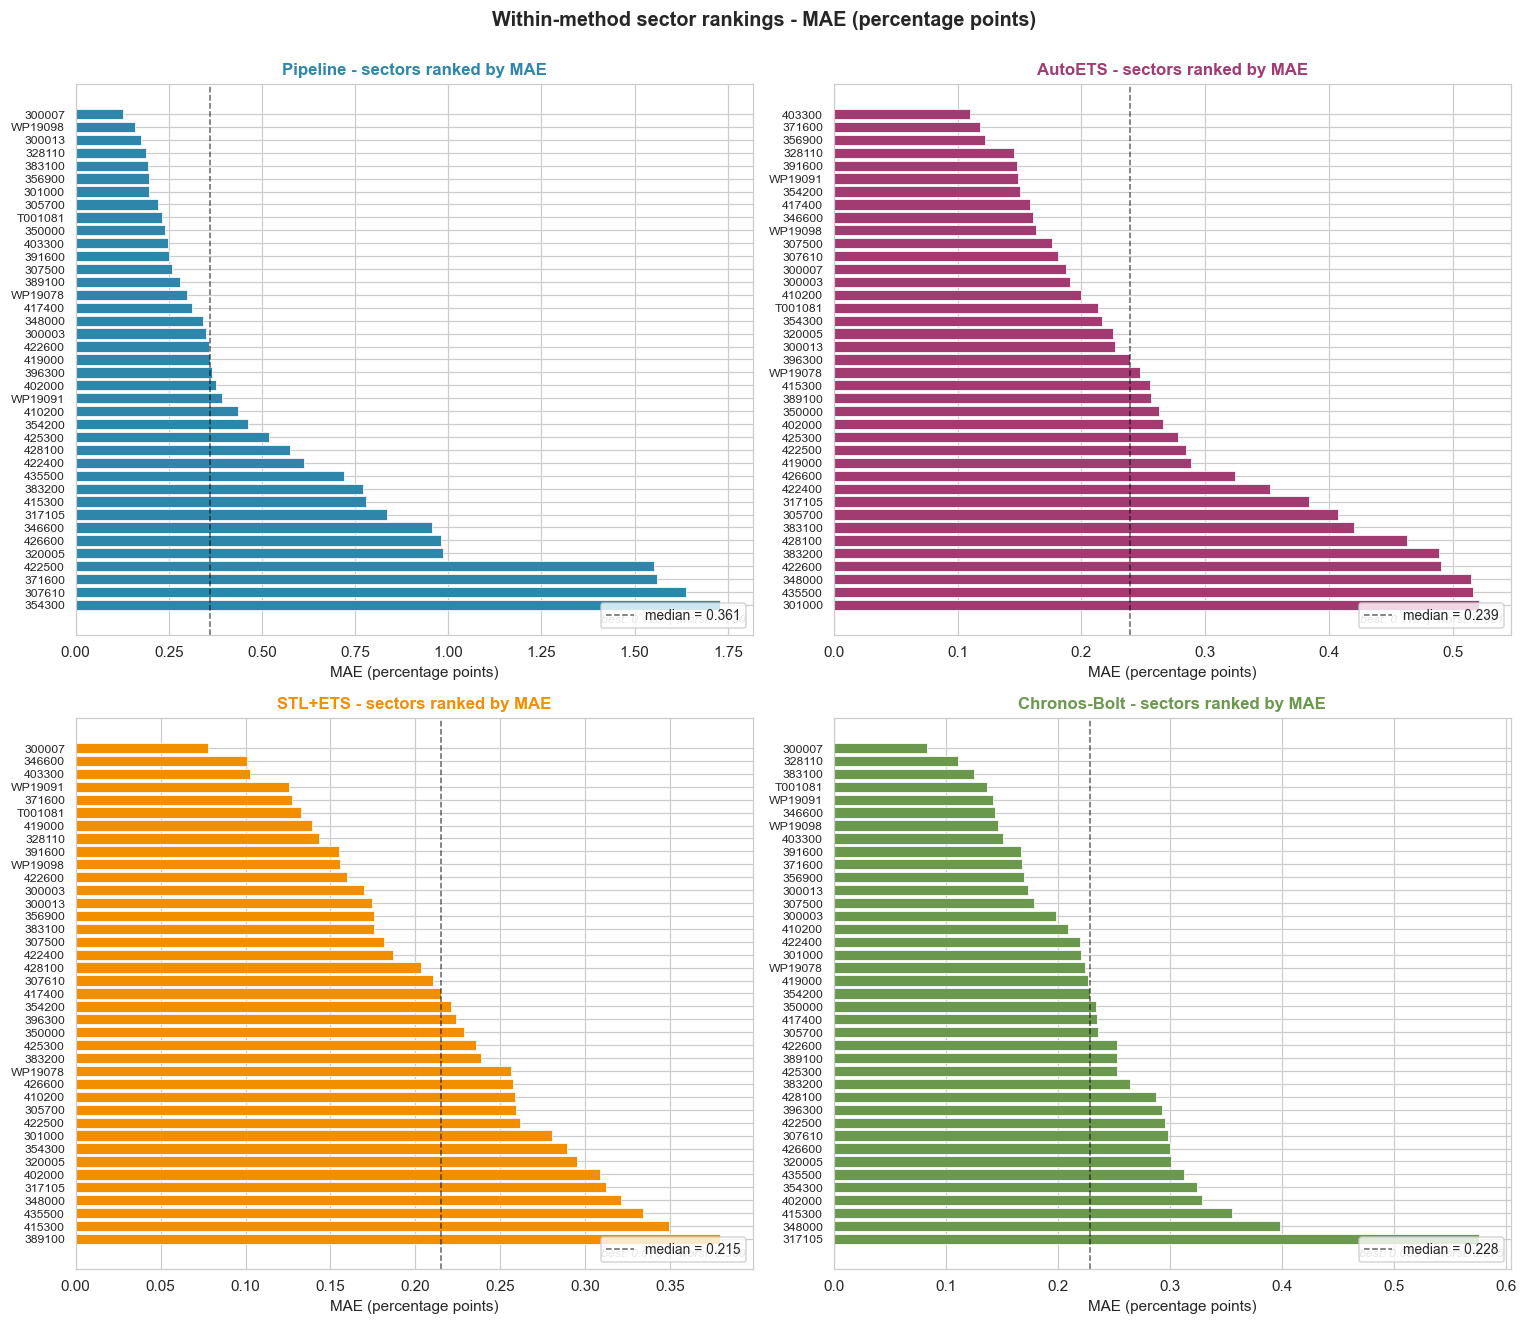

In [10]:
# MAE rankings 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, method in zip(axes, METHOD_ORDER):
    sub = per_sector[per_sector["method"] == method].copy().sort_values("MAE")
    if sub.empty:
        ax.set_visible(False); continue
    color = METHOD_COLORS[method]
    ax.barh(range(len(sub)), sub["MAE"].values, color=color,
            edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["sector_code"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("MAE (percentage points)")
    ax.set_title(f"{METHOD_LABELS[method]} - sectors ranked by MAE",
                 fontsize=11, fontweight='bold', color=color)
    median = sub["MAE"].median()
    ax.axvline(median, color="black", linestyle="--", linewidth=1, alpha=0.6,
               label=f"median = {median:.3f}")
    ax.legend(loc="lower right", fontsize=9)
    ax.text(0.99, 0.02,
            f"best: {sub['MAE'].iloc[0]:.3f}  |  worst: {sub['MAE'].iloc[-1]:.3f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, color="gray", style="italic")

plt.suptitle("Within-method sector rankings - MAE (percentage points)",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


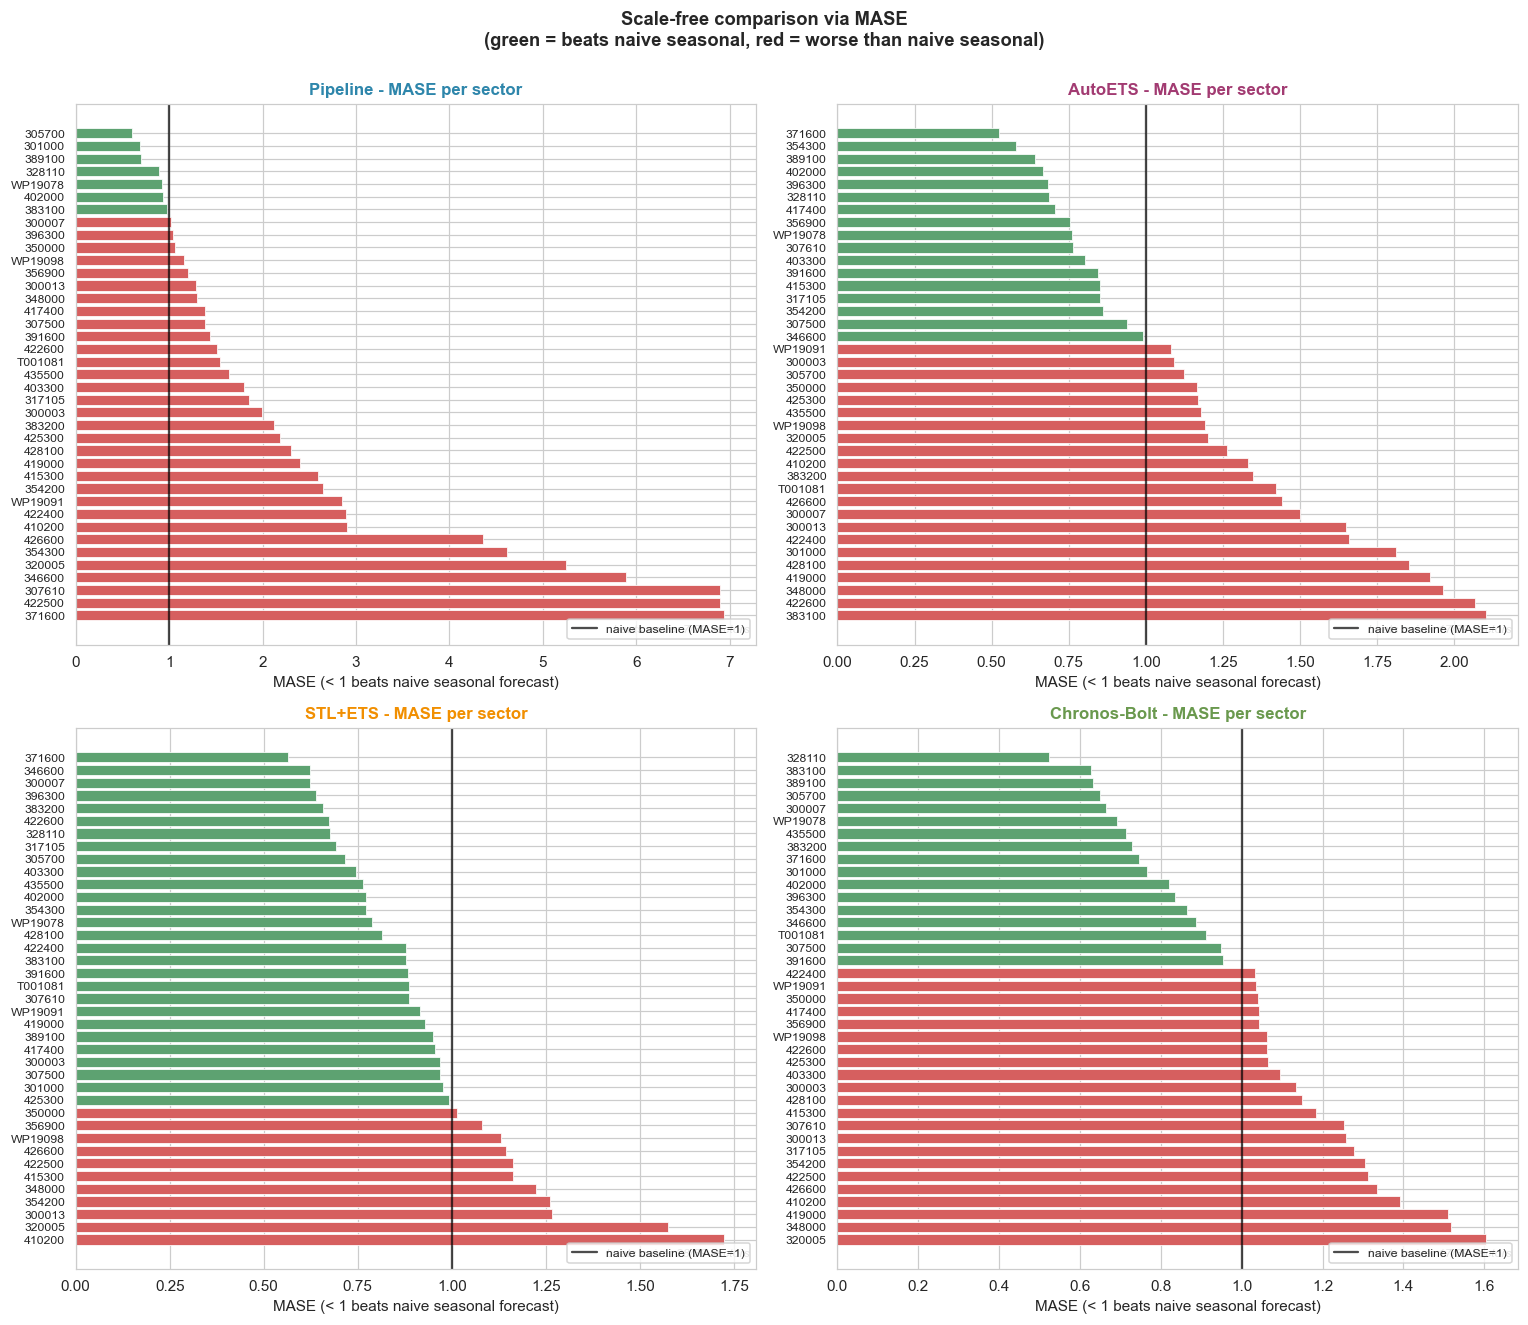

In [11]:
# MASE rankings 2x2 - green bars beat naive baseline, red bars don't
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, method in zip(axes, METHOD_ORDER):
    sub = per_sector[per_sector["method"] == method].dropna(subset=["MASE"]).sort_values("MASE")
    if sub.empty:
        ax.set_visible(False); continue
    bar_colors = ["#5DA271" if v < 1.0 else "#D65F5F" for v in sub["MASE"].values]
    ax.barh(range(len(sub)), sub["MASE"].values, color=bar_colors,
            edgecolor="white", linewidth=0.5)
    ax.axvline(1.0, color="black", linewidth=1.5, alpha=0.7,
               label="naive baseline (MASE=1)")
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["sector_code"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("MASE (< 1 beats naive seasonal forecast)")
    ax.set_title(f"{METHOD_LABELS[method]} - MASE per sector",
                 fontsize=11, fontweight='bold', color=METHOD_COLORS[method])
    n_beat = (sub["MASE"] < 1).sum()
    ax.text(0.99, 0.02, f"beats naive: {n_beat}/{len(sub)} sectors",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, color="gray", style="italic")
    ax.legend(loc="lower right", fontsize=8)

plt.suptitle("Scale-free comparison via MASE\n(green = beats naive seasonal, red = worse than naive seasonal)",
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


### What to look for

- **Tight MAE spread** (best vs worst close together) = method generalizes evenly across sectors.
- **Mostly-green MASE bars** = method consistently beats the naive baseline.
- **A method with green MAE rank but red MASE** = it has low absolute error but only because the sector is inherently easy; it's not adding much over a trivial baseline.
- The **mix** of green and red MASE bars is informative: a method that beats baseline in 28/30 sectors is more trustworthy than one that wins 30/30 by tiny margins.


## 6. Cross-Method Comparison

Per sector, which method wins on MAE?

1. **Heatmap** of (sector x method) MAE, with the winner per row highlighted
2. **Win count** + **winner table**

This is the section your business owner will look at.


In [46]:
import re
from src.utils.m_query_database import f_query_database
from src.config import DIR_DB_SILVER

# ── 1. Load SBI ordering + category groups from the silver DB ───────────
query = """
    SELECT DISTINCT
        BedrijfskenmerkenSBI2008,
        BedrijfskenmerkenSBI2008_Title,
        BedrijfskenmerkenSBI2008_CategoryGroupID
    FROM "80072ned_silver"
    ORDER BY BedrijfskenmerkenSBI2008_CategoryGroupID ASC,
             BedrijfskenmerkenSBI2008_Title ASC
"""
sbi_meta = f_query_database(DIR_DB_SILVER, query, "pandas")
sbi_meta["BedrijfskenmerkenSBI2008"] = sbi_meta["BedrijfskenmerkenSBI2008"].astype(str)

# Strip leading letter + whitespace (covers regular space, non-breaking space, tab)
def _strip_letter_prefix(code):
    code = str(code).strip()
    m = re.match(r"^[A-Za-z][\s\u00a0]+(.+)$", code)
    return m.group(1) if m else code

# Add a normalized matching column to sbi_meta
sbi_meta["_match_code"] = sbi_meta["BedrijfskenmerkenSBI2008"].apply(_strip_letter_prefix)

# Title lookup keyed by BOTH the original silver code and the stripped form,
# so _format_label works no matter which form mase_matrix uses
code_to_title = {}
for _, row in sbi_meta.iterrows():
    orig = str(row["BedrijfskenmerkenSBI2008"])
    norm = row["_match_code"]
    title = row["BedrijfskenmerkenSBI2008_Title"]
    code_to_title[orig] = title
    code_to_title[norm] = title

def _format_label(code, max_len=55):
    title = code_to_title.get(str(code), str(code))
    return title if len(title) <= max_len else title[:max_len - 1] + "…"

# ── 2. Build sector × method MASE matrix (once) ─────────────────────────
mase_matrix = per_sector.pivot(index="sector_code", columns="method", values="MASE")
present_methods = [m for m in METHOD_ORDER if m in mase_matrix.columns]
mase_matrix = mase_matrix[present_methods]
mase_matrix.columns = [METHOD_LABELS[c] for c in mase_matrix.columns]
winner_by_sector = mase_matrix.idxmin(axis=1)

# ── Diagnostic: code-format alignment between sources ───────────────────
direct_overlap     = set(mase_matrix.index) & set(sbi_meta["BedrijfskenmerkenSBI2008"])
normalized_overlap = set(mase_matrix.index) & set(sbi_meta["_match_code"])
print(f"Code matching summary:")
print(f"  per_sector sectors:       {len(mase_matrix.index):>3d}")
print(f"  silver DB rows:           {len(sbi_meta):>3d}")
print(f"  direct match:             {len(direct_overlap):>3d}")
print(f"  match after prefix strip: {len(normalized_overlap):>3d}")
print(f"  sample silver codes:      {sbi_meta['BedrijfskenmerkenSBI2008'].head(3).tolist()}")
print(f"  sample per_sector codes:  {list(mase_matrix.index)[:3]}")
print()

# ── 3. Plotter — column headers on TOP ─────────────────────────────────
def _plot_mase_heatmap(codes, title):
    if not codes:
        print(f"({title}: no sectors to show)")
        return
    sub         = mase_matrix.loc[codes]
    sub_display = sub.copy()
    sub_display.index = [_format_label(s) for s in codes]

    fig, ax = plt.subplots(figsize=(11, max(3.5, len(codes) * 0.32)))
    sns.heatmap(
        sub_display, annot=True, fmt=".2f",
        cmap="RdYlGn_r", center=1.0, vmin=0.5, vmax=2.0,
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "MASE (< 1.0 beats seasonal-naive)"},
        annot_kws={"size": 8},
    )

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontweight="bold")

    for i, sec in enumerate(codes):
        win = winner_by_sector[sec]
        j   = list(sub.columns).index(win)
        winner_value = sub.loc[sec, win]
        if winner_value < 1.0:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor="black", lw=2.5))
        else:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor="#444", lw=1.5, linestyle="--"))

    ax.set_title(title, fontsize=11, fontweight="bold", pad=28)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=9)
    plt.tight_layout()
    plt.show()

# ── 4. One heatmap per CategoryGroupID (groups 1 & 2 combined) ──────────
TABLE_GROUPINGS = [
    ("1 + 2", [1, 2]),
    ("3",     [3]),
    ("4",     [4]),
    ("5",     [5]),
]

available_codes = set(mase_matrix.index)
covered_codes   = set()

for label, group_ids in TABLE_GROUPINGS:
    silver_rows = sbi_meta[
        sbi_meta["BedrijfskenmerkenSBI2008_CategoryGroupID"].isin(group_ids)
    ]

    # For each silver row, find the matching code in mase_matrix.index by
    # trying the original silver code first, then the prefix-stripped form.
    codes_in_group = []
    for _, row in silver_rows.iterrows():
        orig = str(row["BedrijfskenmerkenSBI2008"])
        norm = row["_match_code"]
        if orig in available_codes:
            codes_in_group.append(orig)
        elif norm in available_codes:
            codes_in_group.append(norm)
        # else: silver row has no matching predictions — silently skip

    covered_codes.update(codes_in_group)

    if not codes_in_group:
        print(f"(Category group {label}: no sectors with prediction data)")
        continue

    _plot_mase_heatmap(
        codes_in_group,
        f"Per-sector MASE — Category Group {label}    "
        f"({len(codes_in_group)} sectors)\n"
        f"solid black: winner beats seasonal-naive  |  gray dashed: every method loses",
    )

# ── 5. Diagnostic: sectors in predictions but missing from silver DB ────
missing = available_codes - covered_codes
if missing:
    print(f"\n⚠  {len(missing)} sectors with predictions are NOT in the silver DB "
          f"and therefore not plotted in any of the four tables:")
    for code in sorted(missing):
        print(f"    {code}")
    print(f"\nThese are typically aggregates (T001081) or UWV-specific groupings (WP*)")
    print(f"that don't appear in CBS's 80072ned_silver classification table.")

✅ Query returned 39 rows from silver_data.db as pandas DataFrame


Code matching summary:
  per_sector sectors:        39
  silver DB rows:            39
  direct match:              39
  match after prefix strip:  39
  sample silver codes:      ['T001081', '301000', '300003']
  sample per_sector codes:  ['300003', '300007', '300013']

(Category group 1 + 2: no sectors with prediction data)
(Category group 3: no sectors with prediction data)
(Category group 4: no sectors with prediction data)
(Category group 5: no sectors with prediction data)

⚠  39 sectors with predictions are NOT in the silver DB and therefore not plotted in any of the four tables:
    300003
    300007
    300013
    301000
    305700
    307500
    307610
    317105
    320005
    328110
    346600
    348000
    350000
    354200
    354300
    356900
    371600
    383100
    383200
    389100
    391600
    396300
    402000
    403300
    410200
    415300
    417400
    419000
    422400
    422500
    422600
    425300
    426600
    428100
    435500
    T001081
    WP1907

In [ ]:
# Load baseline predictions, SBI sector titles, and per-method best-configs.
# These power the Final Winners Table at the end of the notebook.

import sqlite3
import json as _json
import warnings as _w
from sqlalchemy import create_engine as _ce, inspect as _sa_inspect

# ── 1. Baseline: SectorQuarterRollingMean predictions from the eval DB ──────
# The pipeline writes per-row predictions for ALL evaluated models (including
# the SectorQuarterRollingMean baseline) into the same table that Pipeline's
# variants live in.  We filter on model_name to extract just the baseline.
_engine = _ce(f"sqlite:///{EVAL_DB.as_posix()}")
_tables = set(_sa_inspect(_engine).get_table_names())
_baseline_table = next(
    (t for t in ("model_evaluation_records", "model_predictions") if t in _tables),
    None,
)

if _baseline_table is None:
    _w.warn(f"No prediction table found in eval DB; baseline comparison disabled. "
            f"Tables present: {sorted(_tables)}")
    baseline_raw = pd.DataFrame(columns=["sector_code", "target_date", "y_true", "y_pred"])
    baseline_mae = pd.Series(dtype=float)
else:
    # Discover the date-column name; pipelines have used both names historically
    _cols = {c["name"] for c in _sa_inspect(_engine).get_columns(_baseline_table)}
    _date_col = "target_date" if "target_date" in _cols else (
                 "fold_target_date" if "fold_target_date" in _cols else None)

    _cols_str = f'sector_code, {_date_col} AS target_date, y_true, y_pred' if _date_col                  else 'sector_code, y_true, y_pred'
    baseline_raw = pd.read_sql(
        f'SELECT {_cols_str} FROM "{_baseline_table}" '
        f"WHERE model_name = 'SectorQuarterRollingMean'",
        _engine,
    )
    baseline_raw["sector_code"] = baseline_raw["sector_code"].astype(str)
    if "target_date" in baseline_raw.columns:
        baseline_raw["target_date"] = pd.to_datetime(baseline_raw["target_date"])
    baseline_raw["abs_err"] = (baseline_raw["y_pred"] - baseline_raw["y_true"]).abs()
    baseline_mae = baseline_raw.groupby("sector_code")["abs_err"].mean()
    print(f"✓ Baseline MAE (SectorQuarterRollingMean) loaded for "
          f"{len(baseline_mae)} sectors from table '{_baseline_table}'")

# ── 2. SBI sector titles from the silver DB ─────────────────────────────────
try:
    from src.config import DIR_DB_SILVER as _DB_SILVER_PATH
except ImportError:
    # Fallback: derive from project root if config is not importable here
    _DB_SILVER_PATH = PROJECT_ROOT / "data" / "2_silver" / "silver_data.db"

try:
    with sqlite3.connect(str(_DB_SILVER_PATH)) as con:
        titles_df = pd.read_sql(
            'SELECT DISTINCT '
            '  BedrijfskenmerkenSBI2008       AS sector_code, '
            '  BedrijfskenmerkenSBI2008_Title AS title '
            'FROM "80072ned_silver"',
            con,
        )
    sbi_titles = dict(zip(titles_df["sector_code"].astype(str), titles_df["title"]))
    print(f"✓ SBI titles loaded for {len(sbi_titles)} codes")
except Exception as _e:
    sbi_titles = {}
    print(f"⚠ Could not load SBI titles ({_e}); winners table will show codes only")

# ── 3. Per-method best-config settings for the winners table ────────────────
def _load_json_maybe(path):
    if not path.exists():
        return {}
    with open(path) as f:
        return _json.load(f)

autoets_settings  = _load_json_maybe(CV_OUTPUT / "autoets_best_configs.json")
stl_ets_settings  = _load_json_maybe(CV_OUTPUT / "stl_ets_best_configs.json")
pipeline_settings = dict(zip(pipeline_winners["sector_code"].astype(str),
                              pipeline_winners["winning_variant"]))
print(f"✓ Best-configs loaded: "
      f"AutoETS={len(autoets_settings)}, "
      f"STL+ETS={len(stl_ets_settings)}, "
      f"Pipeline={len(pipeline_settings)}")

✓ Baseline MAE (SectorQuarterRollingMean) loaded for 0 sectors from table 'model_predictions'
✓ SBI titles loaded for 39 codes
✓ Best-configs loaded: AutoETS=39, STL+ETS=39, Pipeline=39


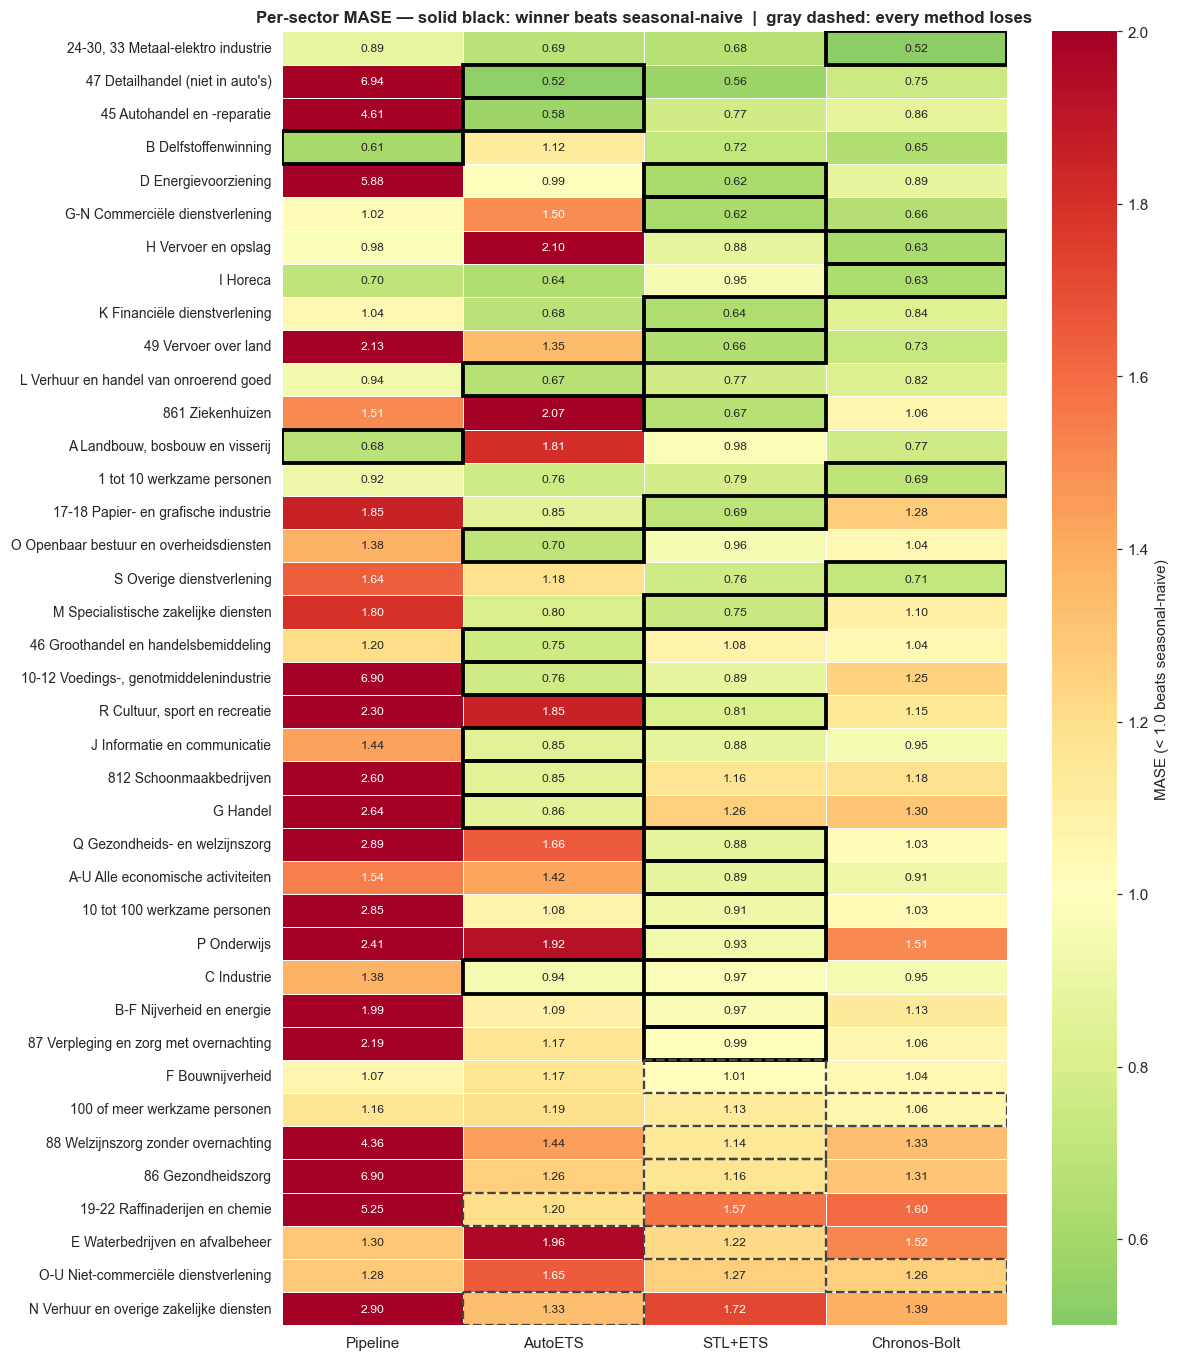


31 of 39 sectors have at least one method that beats the seasonal-naive baseline (MASE < 1.0).
In 8 sectors, no method beats seasonal-naive — in those, the naive forecast would be the right choice.


In [28]:
# ── Build sector_code → title lookup ─────────────────────────────────────
# Tries the common variable names; falls back to codes-only if none found.
sector_to_title = {}
for candidate_name in ("sbi_titles", "sector_titles", "sbi_title_lookup"):
    if candidate_name in dir():
        candidate = eval(candidate_name)
        try:
            sector_to_title = dict(zip(
                candidate["sbi_code"].astype(str),
                candidate["title"],
            ))
            break
        except (KeyError, TypeError, AttributeError):
            try:
                # In case it's already a dict
                sector_to_title = {str(k): v for k, v in candidate.items()}
                break
            except Exception:
                continue
if not sector_to_title:
    print("Warning: no SBI title lookup found — falling back to codes only.")

def _format_label(code, max_len=55):
    """Return SBI title (truncated) if available, else the bare code."""
    title = sector_to_title.get(str(code))
    if not title:
        return str(code)
    return title if len(title) <= max_len else title[:max_len - 1] + "…"

# ── Build sector × method MASE matrix ────────────────────────────────────
mase_matrix = per_sector.pivot(index="sector_code", columns="method", values="MASE")
present_methods = [m for m in METHOD_ORDER if m in mase_matrix.columns]
mase_matrix = mase_matrix[present_methods]
mase_matrix.columns = [METHOD_LABELS[c] for c in mase_matrix.columns]

winner_by_sector = mase_matrix.idxmin(axis=1)
winning_mase = mase_matrix.min(axis=1)

# Sort sectors by lowest (best) MASE
order = winning_mase.sort_values().index
mase_matrix_sorted = mase_matrix.loc[order]

# Replace the index (sector codes) with SBI titles for display
mase_matrix_display = mase_matrix_sorted.copy()
mase_matrix_display.index = [_format_label(s) for s in mase_matrix_sorted.index]

# ── Plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, max(6, len(mase_matrix) * 0.32)))
sns.heatmap(
    mase_matrix_display, annot=True, fmt=".2f",
    cmap="RdYlGn_r", center=1.0, vmin=0.5, vmax=2.0,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "MASE (< 1.0 beats seasonal-naive)"},
    annot_kws={"size": 8},
)

# Outline the winner per row.  Solid black: best method beats naive.
# Gray dashed: even the best method loses to naive in this sector.
for i, sec in enumerate(mase_matrix_sorted.index):
    win = winner_by_sector[sec]
    j = list(mase_matrix_sorted.columns).index(win)
    winner_value = mase_matrix_sorted.loc[sec, win]
    if winner_value < 1.0:
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                    edgecolor="black", lw=2.5))
    else:
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                    edgecolor="#444", lw=1.5, linestyle="--"))

ax.set_title(
    "Per-sector MASE — solid black: winner beats seasonal-naive  |  "
    "gray dashed: every method loses",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

# Headline count for the thesis
n_winners_beat = int((winning_mase < 1.0).sum())
print(f"\n{n_winners_beat} of {len(winning_mase)} sectors have at least one method "
      f"that beats the seasonal-naive baseline (MASE < 1.0).")
print(f"In {len(winning_mase) - n_winners_beat} sectors, no method beats seasonal-naive — "
      f"in those, the naive forecast would be the right choice.")

,method,mean_mase,median_mase,n_beat_naive,n_sectors,pct_beat_naive
0,STL_ETS,0.932,0.887,28,39,71.8%
1,Chronos_Bolt,1.017,1.040,17,39,43.6%
2,AutoETS,1.165,1.124,17,39,43.6%
3,Pipeline,2.361,1.644,7,39,17.9%



STL_ETS        mean MASE = 0.932  (beats seasonal-naive on average, 28/39 sectors)
Chronos_Bolt   mean MASE = 1.017  (loses to seasonal-naive on average, 17/39 sectors)
AutoETS        mean MASE = 1.165  (loses to seasonal-naive on average, 17/39 sectors)
Pipeline       mean MASE = 2.361  (loses to seasonal-naive on average,  7/39 sectors)


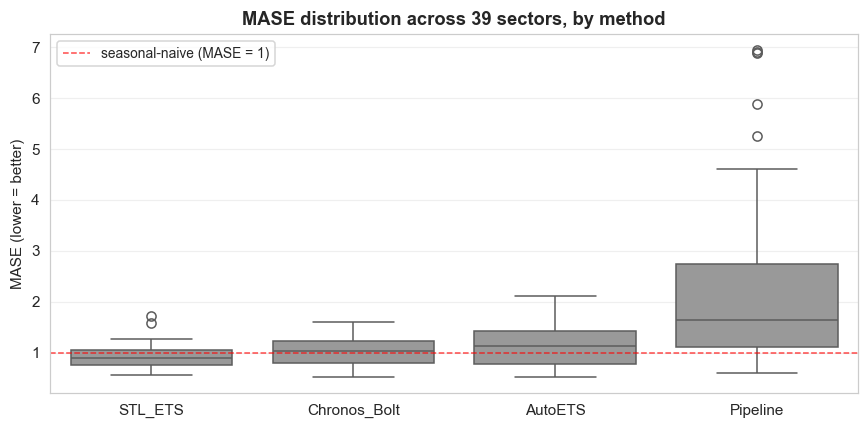

In [24]:
# Mean MASE per method, plus how many of the 39 sectors beat the seasonal-naive baseline.
# MASE < 1.0 means the method beats ŷ_t = y_{t-4}; MASE > 1.0 means it loses to it.
# This is the headline number for the thesis — more interpretable than raw MAE.

mase_summary = (
    per_sector.groupby("method")
              .agg(mean_mase   =("MASE", "mean"),
                   median_mase =("MASE", "median"),
                   n_beat_naive=("MASE", lambda x: int((x < 1.0).sum())),
                   n_sectors   =("MASE", "size"))
              .reset_index()
)
mase_summary["pct_beat_naive"] = (
    mase_summary["n_beat_naive"] / mase_summary["n_sectors"] * 100
).round(1).astype(str) + "%"
mase_summary = mase_summary.sort_values("mean_mase").reset_index(drop=True)

display(
    mase_summary.style
                .format({"mean_mase": "{:.3f}", "median_mase": "{:.3f}"})
                .set_caption("Mean MASE across 39 sectors — lower is better; "
                             "below 1.0 means the method beats seasonal-naive")
                .background_gradient(subset=["mean_mase"], cmap="RdYlGn_r")
)

# Thesis-ready sentences
print()
for _, row in mase_summary.iterrows():
    verdict = "beats" if row["mean_mase"] < 1.0 else "loses to"
    print(f"{row['method']:<14s} mean MASE = {row['mean_mase']:.3f}  "
          f"({verdict} seasonal-naive on average, "
          f"{row['n_beat_naive']:>2d}/{row['n_sectors']} sectors)")

# Optional: distribution view to spot bimodality / outliers
fig, ax = plt.subplots(figsize=(8, 4))
order = mase_summary["method"].tolist()
sns.boxplot(data=per_sector, x="method", y="MASE", order=order,
            palette=[METHOD_COLORS.get(METHOD_LABELS_INVERSE.get(m, m), "#999")
                     if "METHOD_LABELS_INVERSE" in dir() else "#999" for m in order],
            ax=ax)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7,
           label="seasonal-naive (MASE = 1)")
ax.set_title("MASE distribution across 39 sectors, by method", fontweight="bold")
ax.set_ylabel("MASE (lower = better)")
ax.set_xlabel("")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

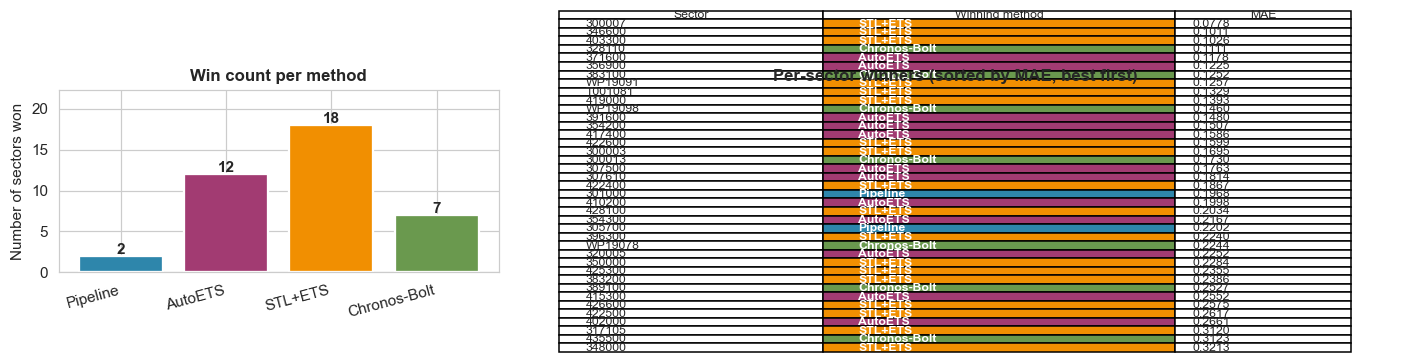

In [13]:
# Win-count bars + winner table
win_counts = winner_by_sector.value_counts().reindex(
    [METHOD_LABELS[m] for m in METHOD_ORDER], fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6),
                               gridspec_kw={"width_ratios": [1, 2]})

colors_for_bars = [METHOD_COLORS[m] for m in METHOD_ORDER]
bars = ax1.bar(range(len(win_counts)), win_counts.values, color=colors_for_bars,
               edgecolor="white", linewidth=1.5)
ax1.set_xticks(range(len(win_counts)))
ax1.set_xticklabels(win_counts.index, rotation=15, ha="right")
ax1.set_ylabel("Number of sectors won")
ax1.set_title("Win count per method", fontsize=11, fontweight='bold')
for bar, v in zip(bars, win_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.3, str(int(v)),
             ha="center", fontsize=10, fontweight='bold')
ax1.set_ylim(0, max(win_counts.values) * 1.18 + 1)

# Winner table
winners_table = pd.DataFrame({
    "sector": winner_by_sector.index,
    "winner": winner_by_sector.values,
    "MAE":    winning_mae.values,
}).sort_values("MAE").reset_index(drop=True)

ax2.axis("off")
ax2.set_title("Per-sector winners (sorted by MAE, best first)",
              fontsize=11, fontweight='bold')

table_data = [["Sector", "Winning method", "MAE"]]
for _, row in winners_table.iterrows():
    table_data.append([str(row["sector"]), str(row["winner"]),
                       f"{row['MAE']:.4f}"])

tbl = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='left', loc='center',
                colWidths=[0.3, 0.4, 0.2])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.0, 1.3)

# Color the winner column by method
label_to_color = {METHOD_LABELS[m]: METHOD_COLORS[m] for m in METHOD_ORDER}
for i, row in winners_table.iterrows():
    cell = tbl[(i + 1, 1)]
    cell.set_facecolor(label_to_color.get(row["winner"], "white"))
    cell.set_text_props(color="white", weight="bold")

plt.tight_layout()
plt.show()


### Reading the cross-method view

- **A dominant method (>50% of wins)** means the comparison has a clear best approach - use that as the default in the report.
- **Roughly even split** means no single method dominates and per-sector selection IS the value-add.
- **A method that never wins** is a deployment-time drop candidate, though it may still be useful as a sanity-check baseline.

The heatmap colours range from green (low MAE) to red (high MAE). A mostly-green row is an easy sector for everyone; a mostly-red row is a hard sector even for the winner. Look for narrow gaps between winning and runner-up - if the difference is tiny (e.g. 0.005 pp), interpretability/maintenance cost might justify deploying the simpler runner-up instead.


## 7. The Quadrant: Univariate x Multivariate, Explainable x Black-Box

For each sector, place a point in the quadrant of its **winning method's paradigm**:

- **X-axis**: univariate (uses only target series) vs multivariate (uses features)
- **Y-axis**: explainable (interpretable model) vs black-box (opaque)

| Method | Univariate? | Explainable? | Quadrant |
|---|---|---|---|
| AutoETS | yes | yes | bottom-left |
| STL+ETS | yes | yes | bottom-left |
| Chronos-Bolt | yes | no | top-left |
| Pipeline (Ridge / ElasticNet / PLS) | no | yes | bottom-right |
| Pipeline (HistGBR) | no | no | top-right |

**What this answers**: does the data demand a particular paradigm, or are the wins distributed across them?

- **Heavy bottom-left**: simple statistical methods are enough; the engineered features aren't pulling weight
- **Heavy bottom-right**: features earn their keep, but linear models capture the structure
- **Heavy top-right**: non-linear feature interactions matter
- **Heavy top-left**: foundation model priors beat your engineered features - unusual and interesting


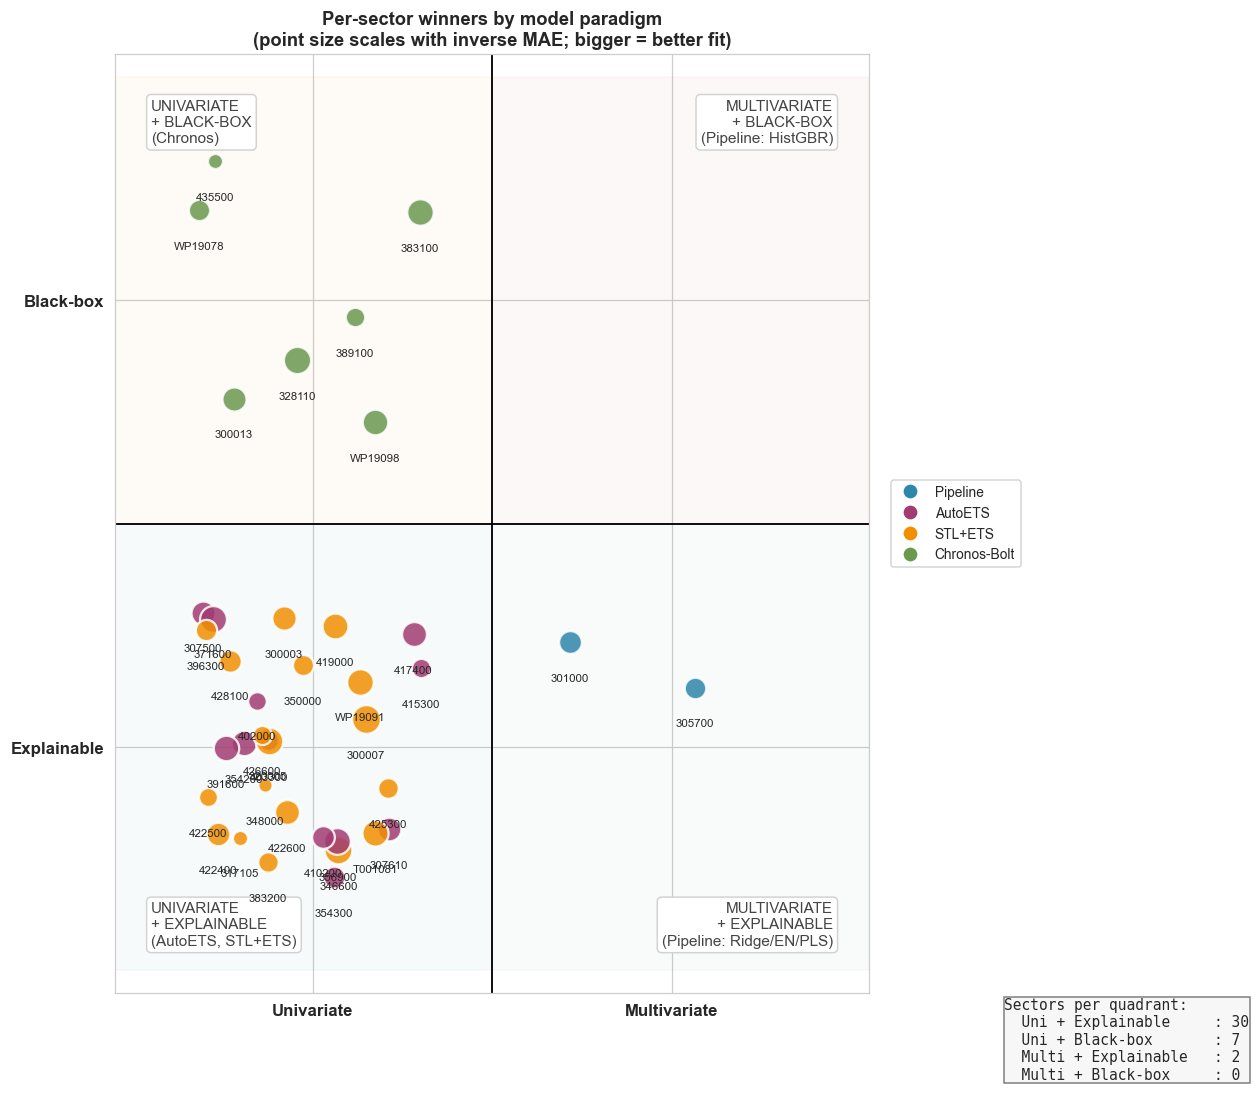

In [14]:
def classify_quadrant(method_label, variant=None):
    """Returns (x, y, color). x/y are quadrant centres (-0.5 or +0.5)."""
    UNI_X, MULTI_X    = -0.5, 0.5
    EXPL_Y, BLACK_Y   = -0.5, 0.5
    if method_label == "Pipeline":
        if variant is None:
            return MULTI_X, EXPL_Y, METHOD_COLORS["Pipeline"]
        v = variant.lower()
        if any(token in v for token in ("hist", "boost", "forest", "rf", "xgb")):
            return MULTI_X, BLACK_Y, METHOD_COLORS["Pipeline"]
        return MULTI_X, EXPL_Y, METHOD_COLORS["Pipeline"]
    if method_label == "AutoETS":     return UNI_X, EXPL_Y, METHOD_COLORS["AutoETS"]
    if method_label == "STL+ETS":     return UNI_X, EXPL_Y, METHOD_COLORS["STL_ETS"]
    if method_label == "Chronos-Bolt": return UNI_X, BLACK_Y, METHOD_COLORS["Chronos_Bolt"]
    return 0, 0, "gray"

pipeline_variant_lookup = dict(zip(
    pipeline_winners["sector_code"].astype(str),
    pipeline_winners["winning_variant"],
))

quadrant_points = []
np.random.seed(42)
for sec in winner_by_sector.index:
    winner_method = winner_by_sector[sec]
    variant = pipeline_variant_lookup.get(str(sec)) if winner_method == "Pipeline" else None
    x, y, color = classify_quadrant(winner_method, variant)
    # Jitter to spread points within quadrant
    x_j = x + np.random.uniform(-0.32, 0.32)
    y_j = y + np.random.uniform(-0.32, 0.32)
    quadrant_points.append({
        "sector": sec, "x": x_j, "y": y_j,
        "method": winner_method, "variant": variant,
        "color": color, "mae": winning_mae[sec],
    })

qdf = pd.DataFrame(quadrant_points)

fig, ax = plt.subplots(figsize=(12, 10))

# Light quadrant fills
ax.axhspan(-1, 0, xmin=0, xmax=0.5, alpha=0.04, color='#2E86AB')
ax.axhspan(-1, 0, xmin=0.5, xmax=1, alpha=0.04, color='#5DA271')
ax.axhspan(0, 1, xmin=0, xmax=0.5, alpha=0.04, color='#F18F01')
ax.axhspan(0, 1, xmin=0.5, xmax=1, alpha=0.04, color='#D65F5F')

ax.axhline(0, color="black", lw=1.2)
ax.axvline(0, color="black", lw=1.2)

ax.text(-0.95, 0.95, "UNIVARIATE\n+ BLACK-BOX\n(Chronos)",
        fontsize=10, va="top", ha="left", color="#444",
        bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.3'))
ax.text(0.95, 0.95, "MULTIVARIATE\n+ BLACK-BOX\n(Pipeline: HistGBR)",
        fontsize=10, va="top", ha="right", color="#444",
        bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.3'))
ax.text(-0.95, -0.95, "UNIVARIATE\n+ EXPLAINABLE\n(AutoETS, STL+ETS)",
        fontsize=10, va="bottom", ha="left", color="#444",
        bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.3'))
ax.text(0.95, -0.95, "MULTIVARIATE\n+ EXPLAINABLE\n(Pipeline: Ridge/EN/PLS)",
        fontsize=10, va="bottom", ha="right", color="#444",
        bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.3'))

# Points - size scales with inverse MAE
max_mae = qdf["mae"].max()
sizes = 350 * (1.25 - qdf["mae"] / max_mae)
for idx, row in qdf.iterrows():
    ax.scatter(row["x"], row["y"], s=max(60, sizes.loc[idx]),
               color=row["color"], edgecolor="white",
               linewidth=1.5, alpha=0.85, zorder=3)
    ax.text(row["x"], row["y"] - 0.07, str(row["sector"]),
            fontsize=7.5, ha="center", va="top", zorder=4)

ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xticks([-0.5, 0.5])
ax.set_xticklabels(["Univariate", "Multivariate"], fontsize=11, fontweight='bold')
ax.set_yticks([-0.5, 0.5])
ax.set_yticklabels(["Explainable", "Black-box"], fontsize=11, fontweight='bold')
ax.set_title("Per-sector winners by model paradigm\n(point size scales with inverse MAE; bigger = better fit)",
             fontsize=12, fontweight='bold')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=METHOD_COLORS[m],
           markersize=10, label=METHOD_LABELS[m])
    for m in METHOD_ORDER
]
ax.legend(handles=legend_elements, loc='center left',
          bbox_to_anchor=(1.02, 0.5), frameon=True)

qsum = {
    "Uni + Explainable":   ((qdf["x"] < 0) & (qdf["y"] < 0)).sum(),
    "Uni + Black-box":     ((qdf["x"] < 0) & (qdf["y"] > 0)).sum(),
    "Multi + Explainable": ((qdf["x"] > 0) & (qdf["y"] < 0)).sum(),
    "Multi + Black-box":   ((qdf["x"] > 0) & (qdf["y"] > 0)).sum(),
}
summary_text = "Sectors per quadrant:\n" + "\n".join(
    f"  {k:22s}: {v}" for k, v in qsum.items()
)
ax.text(1.18, -0.05, summary_text, transform=ax.transAxes,
        fontsize=9.5, va="center", family="monospace",
        bbox=dict(facecolor='#f7f7f7', edgecolor='gray', pad=0.6))

plt.tight_layout()
plt.show()


### Interpreting the quadrant

- A **heavily clustered quadrant** is a clear modelling preference for this data - put it in the report.
- Sectors near a quadrant **border** (where MAE differences are small) are good simpler-model candidates even if a fancier one technically won; deployment cost and interpretability matter.
- **Outliers in unexpected quadrants** deserve manual investigation: why does *this* sector get won by *that* paradigm?


## 8. Per-Horizon Decay

How much does error compound as we forecast further ahead? All models degrade, but at different rates. The right panel normalizes by each method's h=1 error so the *shape* of the decay is comparable across methods at different scales.


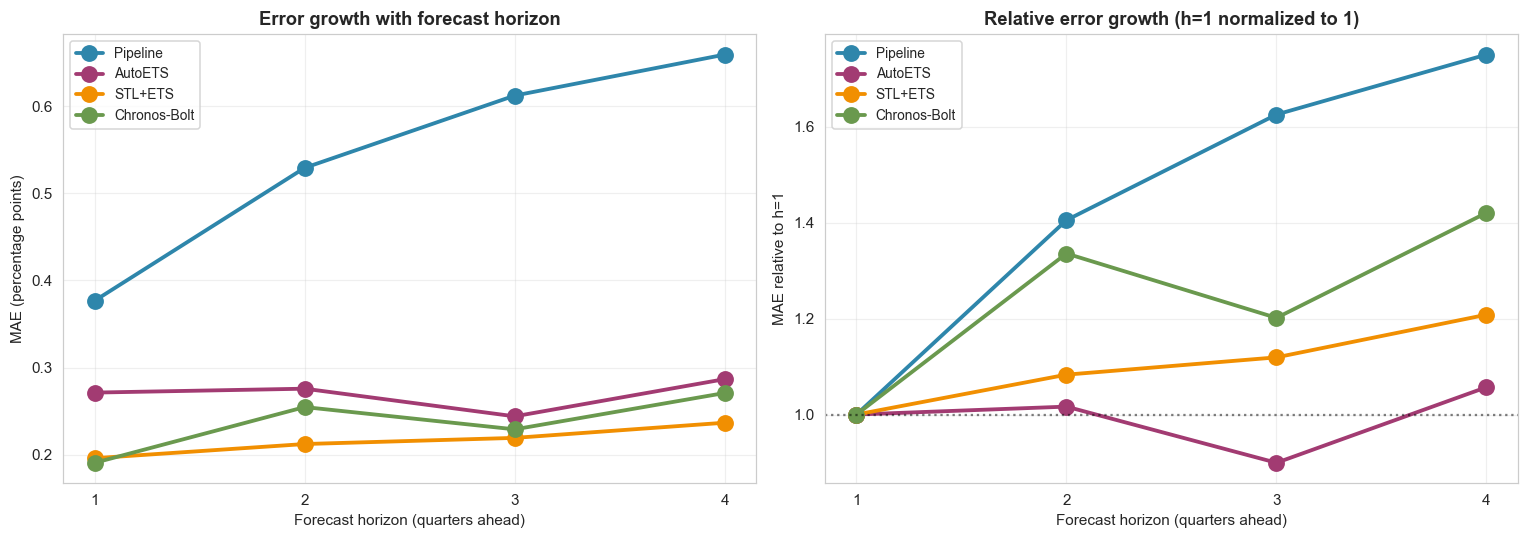


MAE by horizon:
horizon            1       2       3       4
method                                      
Pipeline      0.3768  0.5294  0.6124  0.6595
AutoETS       0.2713  0.2757  0.2440  0.2867
STL+ETS       0.1959  0.2122  0.2192  0.2366
Chronos-Bolt  0.1906  0.2546  0.2290  0.2708


In [15]:
horizon_rows = []
for (method, h), g in aligned.groupby(["model_name", "horizon"]):
    m = compute_metrics(g, NAIVE_BASELINES)
    m.update({"method": METHOD_LABELS[method], "horizon": h})
    horizon_rows.append(m)
horizon_df = pd.DataFrame(horizon_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute MAE by horizon
for method in METHOD_ORDER:
    sub = horizon_df[horizon_df["method"] == METHOD_LABELS[method]].sort_values("horizon")
    if sub.empty: continue
    axes[0].plot(sub["horizon"], sub["MAE"], marker="o", linewidth=2.5,
                 markersize=10, color=METHOD_COLORS[method],
                 label=METHOD_LABELS[method])
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xlabel("Forecast horizon (quarters ahead)")
axes[0].set_ylabel("MAE (percentage points)")
axes[0].set_title("Error growth with forecast horizon", fontsize=12, fontweight='bold')
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Relative degradation
for method in METHOD_ORDER:
    sub = horizon_df[horizon_df["method"] == METHOD_LABELS[method]].sort_values("horizon")
    if sub.empty or not (sub["horizon"] == 1).any():
        continue
    h1 = sub[sub["horizon"] == 1]["MAE"].iloc[0]
    rel = sub["MAE"] / h1
    axes[1].plot(sub["horizon"], rel, marker="o", linewidth=2.5,
                 markersize=10, color=METHOD_COLORS[method],
                 label=METHOD_LABELS[method])
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xlabel("Forecast horizon (quarters ahead)")
axes[1].set_ylabel("MAE relative to h=1")
axes[1].set_title("Relative error growth (h=1 normalized to 1)",
                  fontsize=12, fontweight='bold')
axes[1].axhline(1.0, color="black", linestyle=":", alpha=0.5)
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical table
horizon_table = horizon_df.pivot(index="method", columns="horizon", values="MAE")
horizon_table = horizon_table.reindex([METHOD_LABELS[m] for m in METHOD_ORDER])
print("\nMAE by horizon:")
print(horizon_table.round(4).to_string())


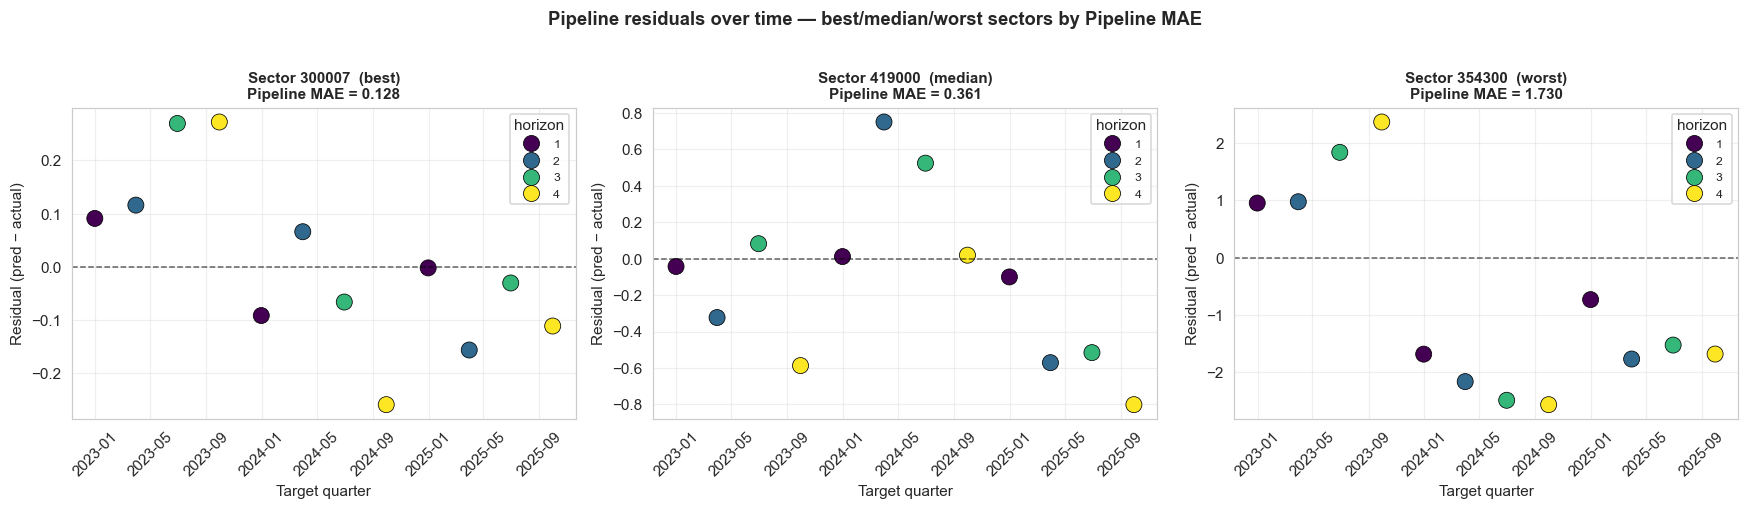

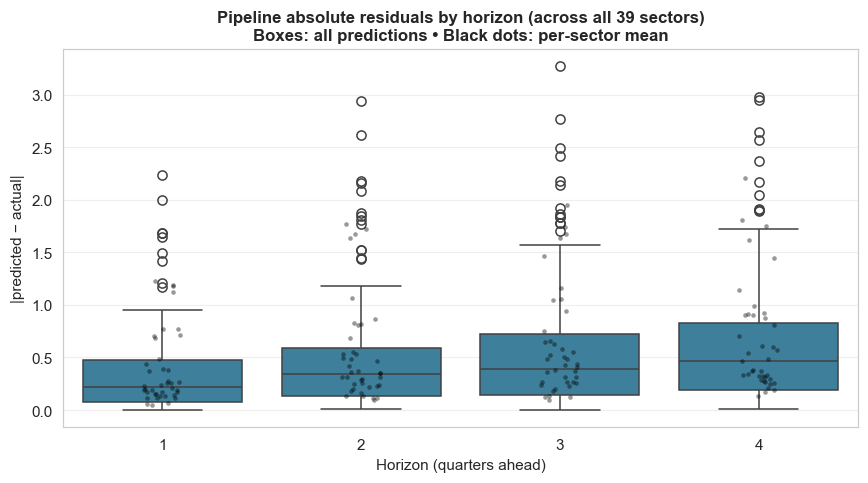

Pipeline absolute residuals by horizon (median ± IQR across all predictions):
  h=1: median=0.217  IQR=[0.080, 0.473]  max=2.237
  h=2: median=0.343  IQR=[0.133, 0.588]  max=2.945
  h=3: median=0.389  IQR=[0.147, 0.728]  max=3.274
  h=4: median=0.469  IQR=[0.188, 0.829]  max=2.976


In [25]:
# Pipeline residuals — investigate whether the error is regime-specific
# (concentrated in particular quarters) or structural (uniformly bad at long horizons).

# Pick representative sectors: best / median / worst Pipeline MAE.
pipeline_mae_by_sector = (
    pipeline.assign(_ae=lambda d: (d["y_pred"] - d["y_true"]).abs())
            .groupby("sector_code")["_ae"]
            .mean()
            .sort_values()
)
example_sectors = [
    pipeline_mae_by_sector.index[0],                                    # best
    pipeline_mae_by_sector.index[len(pipeline_mae_by_sector) // 2],     # median
    pipeline_mae_by_sector.index[-1],                                   # worst
]
example_labels = ["best", "median", "worst"]

# --- Subplots: one per chosen sector, residuals over time, colored by horizon ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, sector, label in zip(axes, example_sectors, example_labels):
    sub = (pipeline[pipeline["sector_code"] == sector]
                 .assign(residual=lambda d: d["y_pred"] - d["y_true"])
                 .sort_values("target_date")
                 .copy())
    sns.scatterplot(
        data=sub, x="target_date", y="residual",
        hue="horizon", palette="viridis",
        s=110, edgecolor="black", linewidth=0.5, ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    mae = sub["residual"].abs().mean()
    ax.set_title(f"Sector {sector}  ({label})\nPipeline MAE = {mae:.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Target quarter")
    ax.set_ylabel("Residual (pred − actual)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(title="horizon", loc="best", fontsize=8)

plt.suptitle("Pipeline residuals over time — best/median/worst sectors by Pipeline MAE",
             y=1.02, fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Direct answer to "does h=4 explode?": absolute residuals by horizon ---
pipeline_all = pipeline.assign(abs_residual=lambda d: (d["y_pred"] - d["y_true"]).abs())

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=pipeline_all, x="horizon", y="abs_residual",
    color=METHOD_COLORS.get("Pipeline", "#2E86AB"),
    showfliers=True, ax=ax,
)
sns.stripplot(
    data=pipeline_all.groupby(["sector_code", "horizon"])["abs_residual"].mean().reset_index(),
    x="horizon", y="abs_residual",
    color="black", alpha=0.4, size=3, ax=ax,
)
ax.set_title("Pipeline absolute residuals by horizon (across all 39 sectors)\n"
             "Boxes: all predictions • Black dots: per-sector mean",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Horizon (quarters ahead)")
ax.set_ylabel("|predicted − actual|")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Numeric summary
print("Pipeline absolute residuals by horizon (median ± IQR across all predictions):")
for h in sorted(pipeline_all["horizon"].unique()):
    s = pipeline_all[pipeline_all["horizon"] == h]["abs_residual"]
    print(f"  h={h}: median={s.median():.3f}  IQR=[{s.quantile(0.25):.3f}, {s.quantile(0.75):.3f}]  "
          f"max={s.max():.3f}")

## 9. Regime Performance: Pre-COVID / COVID / Post-Recovery

Forecasting accuracy depends heavily on the regime. Most methods do well in the stable pre-COVID period; the meaningful differences emerge in the post-2023 "new normal".

The method that holds up post-2023 is the one to deploy.


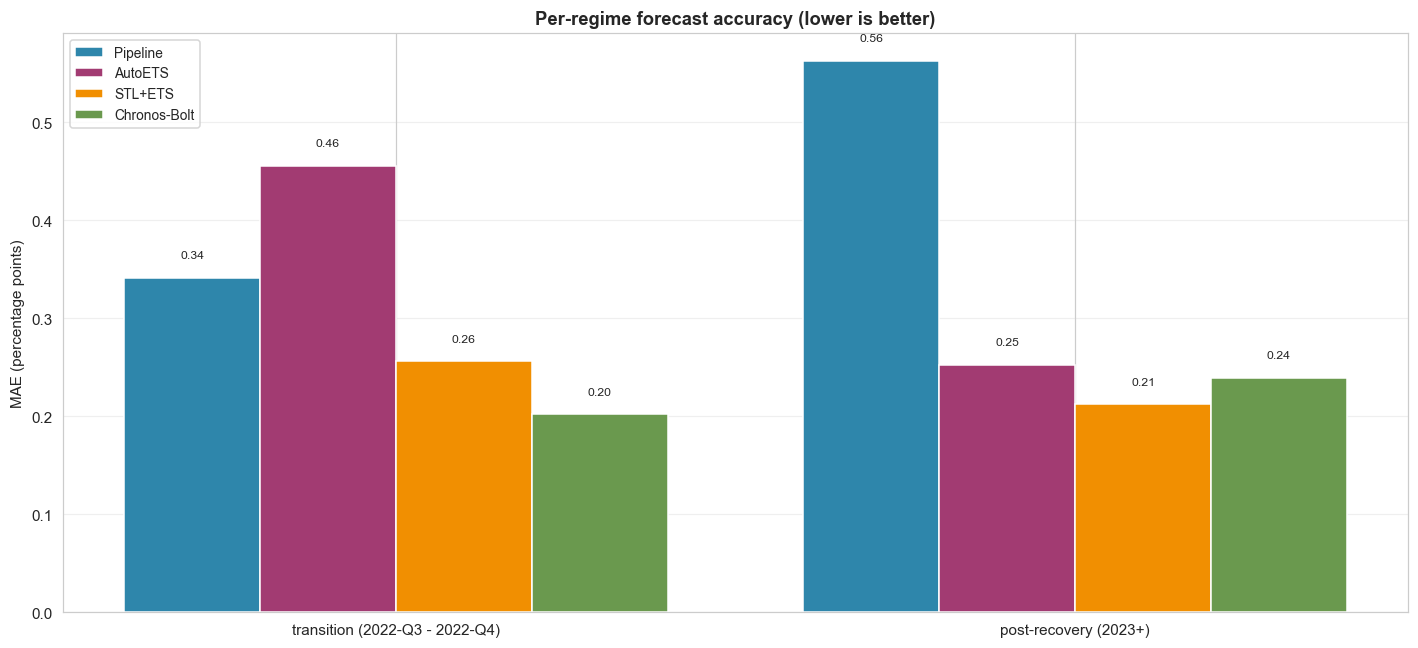

In [16]:
al = aligned.copy()
al["target_date"] = pd.to_datetime(al["target_date"])

def regime_label(d):
    if d < pd.Timestamp("2020-03-31"):
        return "pre-COVID (<=2019)"
    elif d <= pd.Timestamp("2022-06-30"):
        return "COVID (2020-Q1 - 2022-Q2)"
    elif d >= pd.Timestamp("2023-01-01"):
        return "post-recovery (2023+)"
    return "transition (2022-Q3 - 2022-Q4)"

al["regime"] = al["target_date"].map(regime_label)
regime_order = ["pre-COVID (<=2019)", "COVID (2020-Q1 - 2022-Q2)",
                "transition (2022-Q3 - 2022-Q4)", "post-recovery (2023+)"]

regime_rows = []
for (method, reg), g in al.groupby(["model_name", "regime"]):
    if len(g) < 5: continue
    m = compute_metrics(g, NAIVE_BASELINES)
    m.update({"method": METHOD_LABELS[method], "regime": reg})
    regime_rows.append(m)
regime_df = pd.DataFrame(regime_rows)

fig, ax = plt.subplots(figsize=(13, 6))
regimes_present = [r for r in regime_order if r in regime_df["regime"].unique()]
n_methods = len(METHOD_ORDER)
n_regimes = len(regimes_present)
width = 0.8 / n_methods

for i, method in enumerate(METHOD_ORDER):
    vals = []
    for reg in regimes_present:
        sub = regime_df[(regime_df["method"] == METHOD_LABELS[method]) &
                        (regime_df["regime"] == reg)]
        vals.append(sub["MAE"].iloc[0] if len(sub) else np.nan)
    xpos = np.arange(n_regimes) + i * width
    ax.bar(xpos, vals, width, color=METHOD_COLORS[method],
           label=METHOD_LABELS[method], edgecolor="white", linewidth=1)
    for x, v in zip(xpos, vals):
        if not np.isnan(v):
            ax.text(x, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

ax.set_xticks(np.arange(n_regimes) + width * (n_methods - 1) / 2)
ax.set_xticklabels(regimes_present, fontsize=10)
ax.set_ylabel("MAE (percentage points)")
ax.set_title("Per-regime forecast accuracy (lower is better)",
             fontsize=12, fontweight='bold')
ax.legend(loc="upper left")
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Regime narrative for the report

If all methods get worse post-2023 by similar amounts, that's a structural data problem - the world genuinely changed - not a model problem. State it explicitly in the limitations.

If one method holds up where others collapse, that's your deployment recommendation.


## 10. Statistical Significance

Two questions:

1. **Friedman test**: are the rankings of methods across sectors significantly different from random?
2. **Diebold-Mariano (pairwise)**: which specific method-pair differences are statistically significant?

If the Friedman p-value is small (<0.05), at least one method genuinely differs from the others. The pairwise DM matrix tells you *which* differences are real.

If p > 0.05, choose your method on interpretability, runtime, and maintainability rather than raw accuracy.


Friedman omnibus p-value: 0.0000
Sectors evaluated: 39

Mean ranks (lower = better):
  STL+ETS       : 1.74
  Chronos-Bolt  : 2.21
  AutoETS       : 2.44
  Pipeline      : 3.62

Nemenyi critical difference (alpha=0.05): 0.751
  Methods whose mean ranks differ by more than 0.751 are significantly different at the family-wise alpha=0.05 level.


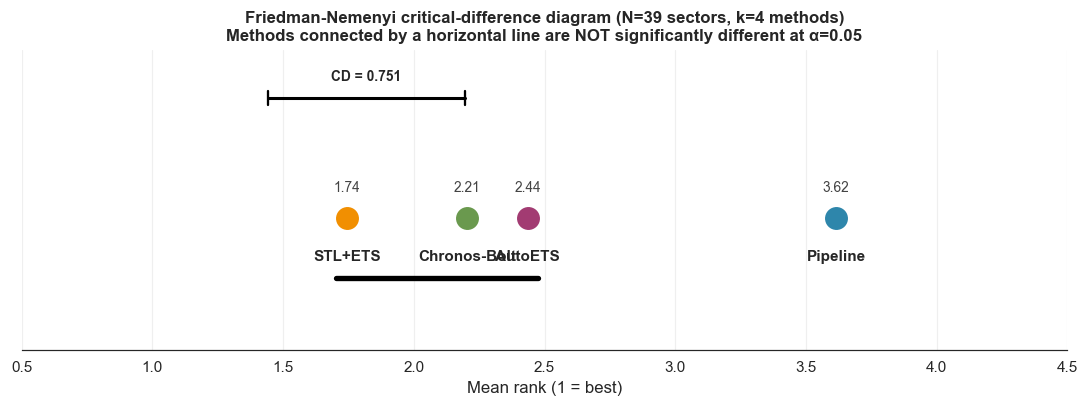


Pairwise Diebold-Mariano p-values (raw / Holm-adjusted; * = significant at alpha=0.05):
                     AutoETS    Chronos-Bolt        Pipeline         STL+ETS
AutoETS          1.0000/nan   0.0074/0.0074*  0.0000/0.0000*  0.0000/0.0000*
Chronos-Bolt  0.0074/0.0074*     1.0000/nan   0.0000/0.0000*  0.0000/0.0001*
Pipeline      0.0000/0.0000*  0.0000/0.0000*     1.0000/nan   0.0000/0.0000*
STL+ETS       0.0000/0.0000*  0.0000/0.0001*  0.0000/0.0000*     1.0000/nan 

Win-loss matrix (row beats column on N sectors at p < 0.05, raw):
              AutoETS Chronos-Bolt Pipeline  STL+ETS
AutoETS             —       1-6-32  14-3-22   3-9-27
Chronos-Bolt   6-1-32            —  16-0-23   1-2-36
Pipeline      3-14-22      0-16-23        —  1-19-19
STL+ETS        9-3-27       2-1-36  19-1-19        —


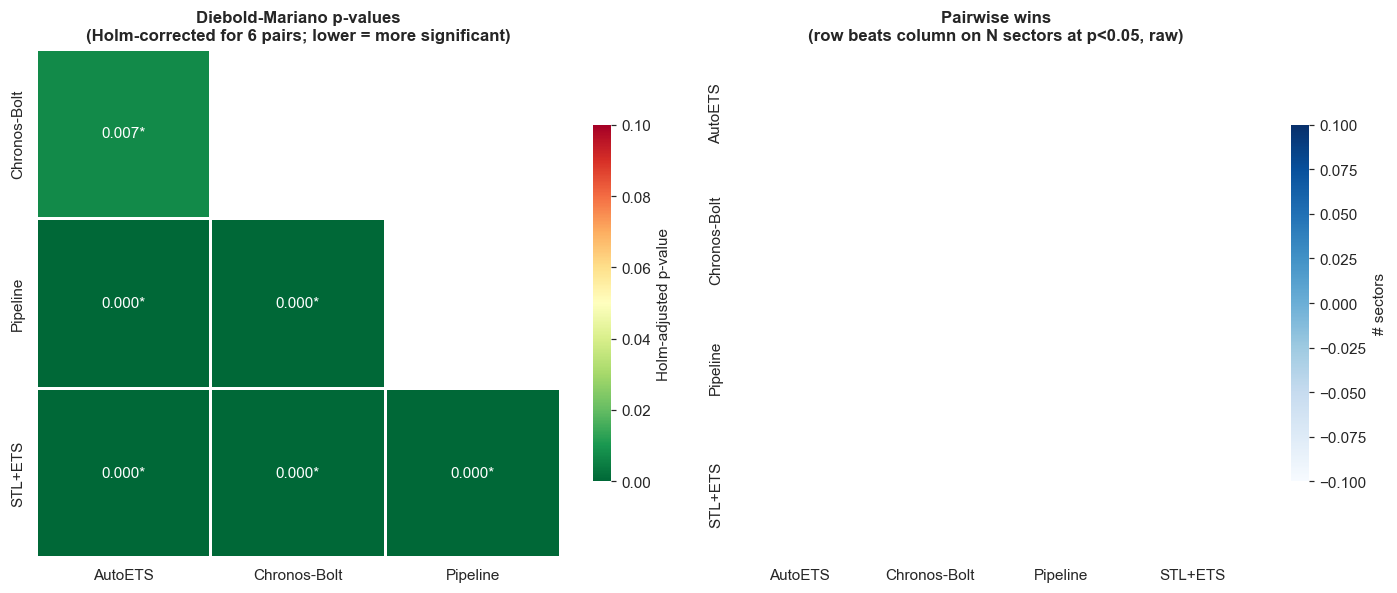

In [17]:
# Friedman-Nemenyi (rank-based, non-parametric, properly controls family-wise
# error rate via Critical Difference) and Diebold-Mariano with Holm-Bonferroni
# correction for multiple comparisons (k(k-1)/2 = 6 pair tests).

try:
    fr = friedman_nemenyi(aligned)
    print(f"Friedman omnibus p-value: {fr.get('friedman_p'):.4f}")
    print(f"Sectors evaluated: {fr.get('n_sectors')}")
    if fr.get('mean_ranks'):
        print(f"\nMean ranks (lower = better):")
        for m, r in sorted(fr['mean_ranks'].items(), key=lambda kv: kv[1]):
            print(f"  {METHOD_LABELS.get(m, m):14s}: {r:.2f}")

        # --- Critical-difference diagram (Demšar 2006 style) ---
        k = len(fr['mean_ranks'])
        N = fr['n_sectors']
        try:
            from scipy.stats import studentized_range
            q_alpha = studentized_range.ppf(0.95, k, np.inf) / np.sqrt(2)
        except (ImportError, AttributeError):
            q_alpha = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850}.get(k, 2.569)
        CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
        print(f"\nNemenyi critical difference (alpha=0.05): {CD:.3f}")
        print(f"  Methods whose mean ranks differ by more than {CD:.3f} are "
              f"significantly different at the family-wise alpha=0.05 level.")

        sorted_items   = sorted(fr['mean_ranks'].items(), key=lambda kv: kv[1])
        methods_keys   = [m for m, _ in sorted_items]
        methods_labels = [METHOD_LABELS.get(m, m) for m in methods_keys]
        ranks          = [r for _, r in sorted_items]

        with sns.axes_style("white"):
            fig, ax = plt.subplots(figsize=(10, 3.8))
            y_dot = 0.55
            for i, (label, rank, mkey) in enumerate(zip(methods_labels, ranks, methods_keys)):
                color = METHOD_COLORS.get(mkey, "gray")
                ax.plot(rank, y_dot, "o", markersize=14, color=color, zorder=3)
                ax.text(rank, y_dot - 0.18, label,           ha="center", fontsize=10, fontweight="bold")
                ax.text(rank, y_dot + 0.11, f"{rank:.2f}",   ha="center", fontsize=9,  color="#444")

            x0 = max(0.7, min(ranks) - 0.3)
            ax.plot([x0, x0 + CD], [1.05, 1.05], "k-", linewidth=2)
            ax.plot([x0, x0],            [1.02, 1.08], "k-")
            ax.plot([x0 + CD, x0 + CD],  [1.02, 1.08], "k-")
            ax.text(x0 + CD / 2, 1.12, f"CD = {CD:.3f}", ha="center", fontsize=9, fontweight="bold")

            # Connect adjacent groups whose rank gap is below CD (not sig. different)
            groups, current = [], [0]
            for i in range(1, len(ranks)):
                if ranks[i] - ranks[current[0]] < CD:
                    current.append(i)
                else:
                    if len(current) > 1:
                        groups.append(current)
                    current = [i]
            if len(current) > 1:
                groups.append(current)
            for g_idx, g in enumerate(groups):
                x_start = ranks[g[0]]  - 0.04
                x_end   = ranks[g[-1]] + 0.04
                y_line  = 0.30 - g_idx * 0.06
                ax.plot([x_start, x_end], [y_line, y_line], "k-", linewidth=3.5)

            ax.set_xlim(0.5, k + 0.5)
            ax.set_ylim(0, 1.25)
            ax.set_yticks([])
            ax.set_xlabel("Mean rank (1 = best)", fontsize=11)
            ax.set_title(f"Friedman-Nemenyi critical-difference diagram (N={N} sectors, k={k} methods)\n"
                         f"Methods connected by a horizontal line are NOT significantly different at α=0.05",
                         fontsize=11, fontweight="bold")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.set_facecolor("white")
            ax.grid(axis="x", alpha=0.3)
            plt.tight_layout()
            plt.show()
except Exception as e:
    print(f"Friedman test could not run: {type(e).__name__}: {e}")

print()

try:
    dm_result = pairwise_dm_matrix(aligned, alpha=0.05)
    if isinstance(dm_result, tuple):
        dm_pvals   = dm_result[0]
        dm_winloss = dm_result[1] if len(dm_result) > 1 else None
    else:
        dm_pvals, dm_winloss = dm_result, None

    # Friendly labels
    if hasattr(dm_pvals, "rename"):
        dm_pvals = dm_pvals.rename(index=METHOD_LABELS, columns=METHOD_LABELS)
    if dm_winloss is not None and hasattr(dm_winloss, "rename"):
        dm_winloss = dm_winloss.rename(index=METHOD_LABELS, columns=METHOD_LABELS)

    # --- Holm-Bonferroni correction over the k*(k-1)/2 unique pairs ---
    # Pull out unique p-values (upper triangle), order them, apply Holm.
    methods_in_dm = list(dm_pvals.columns)
    pair_pvals = []
    for i in range(len(methods_in_dm)):
        for j in range(i + 1, len(methods_in_dm)):
            p = dm_pvals.iat[i, j]
            if pd.notna(p):
                pair_pvals.append(((methods_in_dm[i], methods_in_dm[j]), float(p)))
    pair_pvals.sort(key=lambda x: x[1])
    n_pairs = len(pair_pvals)
    holm_adjusted = {}
    running_max = 0.0
    for k_idx, ((a, b), p) in enumerate(pair_pvals):
        adj = min(1.0, p * (n_pairs - k_idx))
        running_max = max(running_max, adj)   # enforce monotonicity
        holm_adjusted[(a, b)] = running_max
        holm_adjusted[(b, a)] = running_max

    dm_pvals_holm = pd.DataFrame(np.nan, index=dm_pvals.index, columns=dm_pvals.columns)
    for (a, b), p_adj in holm_adjusted.items():
        if a in dm_pvals_holm.index and b in dm_pvals_holm.columns:
            dm_pvals_holm.at[a, b] = p_adj

    # --- Text print: raw + Holm-adjusted p-values with significance stars ---
    print("Pairwise Diebold-Mariano p-values (raw / Holm-adjusted; * = significant at alpha=0.05):")

    def _annotate(p_raw, p_holm):
        if pd.isna(p_raw): return ""
        s_holm = "*" if p_holm < 0.05 else " "
        return f"{p_raw:.4f}/{p_holm:.4f}{s_holm}"

    annot_text = pd.DataFrame(
        [[_annotate(dm_pvals.iat[i, j], dm_pvals_holm.iat[i, j])
          for j in range(dm_pvals.shape[1])]
         for i in range(dm_pvals.shape[0])],
        index=dm_pvals.index, columns=dm_pvals.columns,
    )
    print(annot_text.to_string())

    if dm_winloss is not None:
        # Replace string sentinels ("—") on the diagonal with NaN for plotting
        dm_winloss_for_plot = dm_winloss.copy()
        for c in dm_winloss_for_plot.columns:
            dm_winloss_for_plot[c] = pd.to_numeric(dm_winloss_for_plot[c], errors="coerce")
        print(f"\nWin-loss matrix (row beats column on N sectors at p < 0.05, raw):")
        print(dm_winloss.to_string())

    # --- Visualization: Holm-corrected p-value heatmap + win-loss heatmap ---
    sub_pvals = dm_pvals_holm.iloc[1:, :-1].copy()
    mask = np.triu(np.ones_like(sub_pvals, dtype=bool), k=1)
    annot = sub_pvals.applymap(
        lambda p: "" if pd.isna(p) else f"{p:.3f}{'*' if p < 0.05 else ''}"
    )

    with sns.axes_style("white"):
        fig, axes = plt.subplots(1, 2 if dm_winloss is not None else 1,
                                  figsize=(13 if dm_winloss is not None else 7, 5.5))
        ax_p = axes[0] if dm_winloss is not None else axes

        sns.heatmap(
            sub_pvals, mask=mask, annot=annot, fmt="",
            cmap="RdYlGn_r", vmin=0, vmax=0.10, center=0.05,
            linewidths=0.8, linecolor="white",
            cbar_kws={"label": "Holm-adjusted p-value", "shrink": 0.7},
            ax=ax_p,
        )
        ax_p.set_title("Diebold-Mariano p-values\n(Holm-corrected for 6 pairs; lower = more significant)",
                       fontsize=11, fontweight="bold")
        ax_p.set_xlabel(""); ax_p.set_ylabel("")
        ax_p.set_facecolor("white"); ax_p.grid(False)
        for spine in ax_p.spines.values():
            spine.set_visible(False)

        if dm_winloss is not None:
            ax_w = axes[1]
            sns.heatmap(
                dm_winloss_for_plot, annot=True, fmt=".0f",
                cmap="Blues", vmin=0,
                linewidths=0.8, linecolor="white",
                cbar_kws={"label": "# sectors", "shrink": 0.7},
                ax=ax_w,
            )
            ax_w.set_title("Pairwise wins\n(row beats column on N sectors at p<0.05, raw)",
                           fontsize=11, fontweight="bold")
            ax_w.set_xlabel(""); ax_w.set_ylabel("")
            ax_w.set_facecolor("white"); ax_w.grid(False)
            for spine in ax_w.spines.values():
                spine.set_visible(False)

        plt.tight_layout()
        plt.show()

except Exception as e:
    import traceback
    print(f"DM matrix could not run: {type(e).__name__}: {e}")
    traceback.print_exc()

## 11. Sensitivity Analysis: Gold-Imputed vs Real-Data-Only Inputs

The gold table's `impute_target_variable` forward-fills NaN gaps grouped by `BedrijfstakkenBranchesSBI2008` — a broader classification than the per-sector `BedrijfskenmerkenSBI2008` we iterate over.  For the 13 sectors with 2004-2007 (or 2004-2005) reorganization gaps, that grouped ffill borrows values from *sibling sectors* in the same branch, not from the same sector's prior quarters.  Those borrowed quarters are not real observations from the affected sectors.

By default the three CV scripts read from the gold table, guaranteeing identical inputs across all four methods.  But the imputed values do enter the univariate methods' training data — and ETS-family methods aren't designed to consume cross-sector borrowed values.

This sensitivity check re-runs the three CV scripts on silver with contiguous-tail extraction (no fabricated values) and compares per-sector MAE between the two input regimes.  The 26 sectors without gaps should produce identical predictions in both regimes (sanity check).  For the 13 reorganized sectors, predictions may differ — and the direction of the delta tells us whether gold's imputation helped or hurt each method.

To run the silver counterpart of each script:

```bash
uv run python run_autoets_cv.py  --data-source silver
uv run python run_stl_ets_cv.py  --data-source silver
uv run python run_chronos_cv.py  --data-source silver
```

These write `*_predictions_silver.parquet` files alongside the primary gold outputs.

In [18]:
# Load silver-data counterparts of the three CV runs.
# Pipeline isn't re-run — it always trains on the gold table.

silver_paths = {
    "AutoETS":      CV_OUTPUT / "autoets_predictions_silver.parquet",
    "STL_ETS":      CV_OUTPUT / "stl_ets_predictions_silver.parquet",
    "Chronos_Bolt": CV_OUTPUT / "chronos_predictions_silver.parquet",
}
gold_runs = {
    "AutoETS":      autoets,
    "STL_ETS":      stl_ets,
    "Chronos_Bolt": chronos,
}
silver_runs = {}
missing = []

for name, p in silver_paths.items():
    if not p.exists():
        missing.append(p.name)
        continue
    if name == "AutoETS":
        silver_runs[name] = load_autoets_predictions(p)
    elif name == "STL_ETS":
        silver_runs[name] = load_stl_ets_predictions(p)
    elif name == "Chronos_Bolt":
        silver_runs[name] = load_chronos_predictions(p)

if missing:
    print(f"⚠ Silver runs missing: {missing}")
    print(f"  Generate them with `--data-source silver` on each script, then re-run this cell.")
    print(f"  Skipping sensitivity analysis.")
else:
    print(f"✓ Loaded silver-data predictions for {list(silver_runs)}")
    for name, df in silver_runs.items():
        print(f"    {METHOD_LABELS[name]:<14s}  {len(df):>5,} rows  "
              f"{df['sector_code'].nunique():>3} sectors  "
              f"{fmt_quarter(df['target_date'].min())} → {fmt_quarter(df['target_date'].max())}")

✓ Loaded silver-data predictions for ['AutoETS', 'STL_ETS', 'Chronos_Bolt']
    AutoETS         2,844 rows   39 sectors  2020-Q1 → 2025-Q3
    STL+ETS         8,896 rows   39 sectors  2009-Q1 → 2025-Q3
    Chronos-Bolt    1,872 rows   39 sectors  2022-Q1 → 2025-Q3


In [19]:
# Build the per-sector gold-vs-silver MAE comparison table.
# Align on (sector_code, target_date) so we compare predictions made for the
# same forecast targets — fair regardless of differing fold structures.

EPS = 1e-6
sensitivity_rows = []

for method, df_silver in silver_runs.items():
    df_gold = gold_runs[method]
    keys = ["sector_code", "target_date"]
    join = df_gold[keys + ["y_true", "y_pred"]].merge(
        df_silver[keys + ["y_pred"]],
        on=keys,
        suffixes=("_gold", "_silver"),
    )
    if join.empty:
        continue
    join["abs_err_gold"]   = (join["y_pred_gold"]   - join["y_true"]).abs()
    join["abs_err_silver"] = (join["y_pred_silver"] - join["y_true"]).abs()

    per_sector_delta = (join.groupby("sector_code")
                      .agg(n_common_preds=("y_true",         "count"),
                           mae_gold      =("abs_err_gold",   "mean"),
                           mae_silver    =("abs_err_silver", "mean"))
                      .reset_index())
    per_sector_delta["delta"]  = per_sector_delta["mae_silver"] - per_sector_delta["mae_gold"]
    per_sector_delta["method"] = method
    sensitivity_rows.append(per_sector_delta)

sensitivity = (pd.concat(sensitivity_rows, ignore_index=True)
               if sensitivity_rows else pd.DataFrame())

if sensitivity.empty:
    print("No common (sector, target_date) pairs between gold and silver runs.")
else:
    # Affected = predictions differ between gold and silver beyond floating-point noise
    affected   = sensitivity[sensitivity["delta"].abs() >  EPS].copy()
    unaffected = sensitivity[sensitivity["delta"].abs() <= EPS].copy()

    print(f"(method, sector) pairs with identical predictions in both regimes: "
          f"{len(unaffected)}  ← sanity check; expected for sectors without gaps")
    print(f"(method, sector) pairs with differing predictions:                 "
          f"{len(affected)}")
    print(f"Unique sectors affected by data-source choice: "
          f"{affected['sector_code'].nunique()}")
    if not affected.empty:
        codes = sorted(affected['sector_code'].unique())
        print(f"\nAffected sector codes: {codes}")

(method, sector) pairs with identical predictions in both regimes: 58  ← sanity check; expected for sectors without gaps
(method, sector) pairs with differing predictions:                 59
Unique sectors affected by data-source choice: 27

Affected sector codes: ['300013', '301000', '307500', '317105', '320005', '328110', '346600', '348000', '350000', '354200', '356900', '371600', '389100', '391600', '402000', '403300', '410200', '415300', '419000', '422400', '422500', '422600', '425300', '426600', '428100', '435500', 'WP19078']


Per-method aggregate over affected sectors:

              n_sectors  mean_mae_gold  mean_mae_silver  mean_delta  median_delta  improved  worsened
method                                                                                               
AutoETS              27          0.517            0.498      -0.019        -0.019        15        12
STL_ETS              16          0.306            0.280      -0.026        -0.016        12         4
Chronos_Bolt         16          0.316            0.294      -0.022        -0.015        11         5

Reading guide:
  delta = MAE_silver − MAE_gold (per sector, then averaged)
  delta < 0 → silver+tail forecasts BETTER  (gold imputation hurt the method)
  delta > 0 → silver+tail forecasts WORSE   (gold's extra training data helped)
  improved / worsened columns count sectors crossing the ±EPS threshold


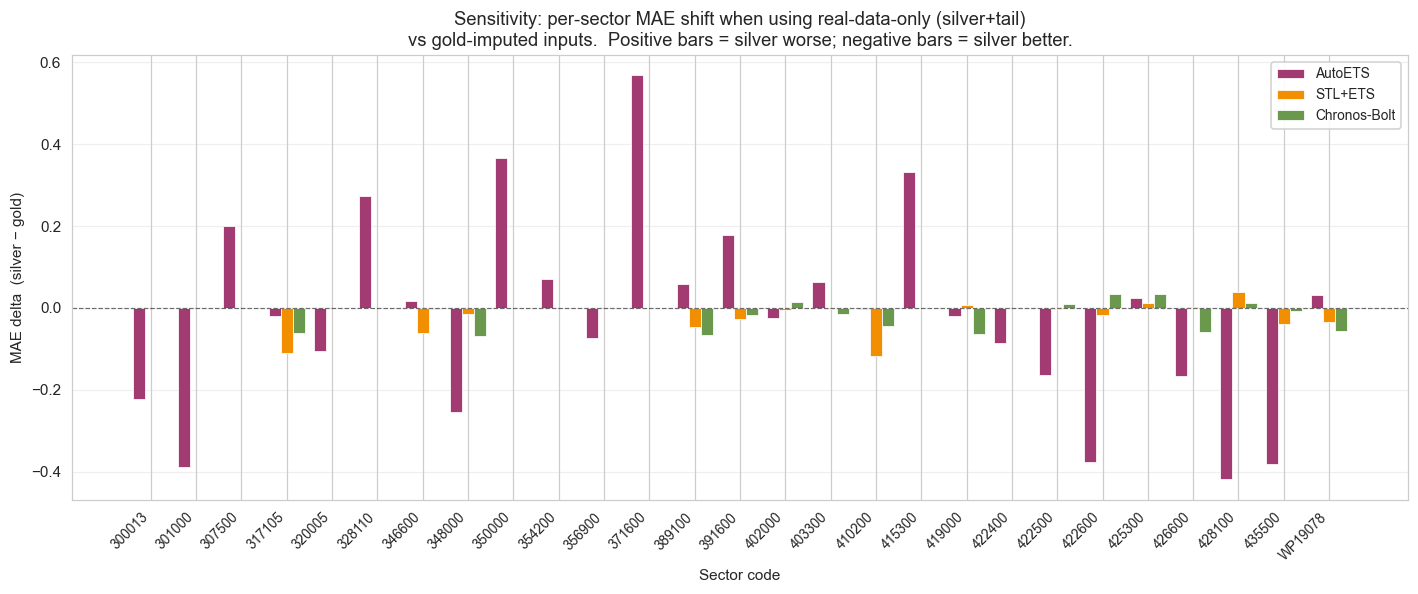

In [20]:
# Per-method aggregates over the affected sectors + delta bar chart.

if sensitivity.empty or affected.empty:
    print("Nothing to plot — no sectors show differing predictions.")
else:
    agg = (affected.groupby("method")
                   .agg(n_sectors      =("sector_code", "nunique"),
                        mean_mae_gold  =("mae_gold",    "mean"),
                        mean_mae_silver=("mae_silver",  "mean"),
                        mean_delta     =("delta",       "mean"),
                        median_delta   =("delta",       "median"),
                        improved       =("delta",       lambda x: int((x < -EPS).sum())),
                        worsened       =("delta",       lambda x: int((x >  EPS).sum())))
                   .round(3)
                   .loc[[m for m in ["AutoETS", "STL_ETS", "Chronos_Bolt"]
                         if m in affected['method'].unique()]])

    print("Per-method aggregate over affected sectors:\n")
    print(agg.to_string())

    print("\nReading guide:")
    print("  delta = MAE_silver − MAE_gold (per sector, then averaged)")
    print("  delta < 0 → silver+tail forecasts BETTER  (gold imputation hurt the method)")
    print("  delta > 0 → silver+tail forecasts WORSE   (gold's extra training data helped)")
    print("  improved / worsened columns count sectors crossing the ±EPS threshold")

    # ── Visualization: per-sector delta bars, grouped by method ──
    methods_in_plot = [m for m in ["AutoETS", "STL_ETS", "Chronos_Bolt"]
                        if m in affected['method'].unique()]
    sectors_in_plot = sorted(affected['sector_code'].unique())

    pivot = (affected.pivot(index="sector_code", columns="method", values="delta")
                     .reindex(sectors_in_plot)
                     [methods_in_plot])

    fig, ax = plt.subplots(figsize=(13, 5.5))
    x = np.arange(len(pivot))
    n = len(methods_in_plot)
    w = 0.8 / n

    for i, method in enumerate(methods_in_plot):
        offset = (i - (n - 1) / 2) * w
        ax.bar(x + offset, pivot[method].values, w,
               label=METHOD_LABELS[method],
               color=METHOD_COLORS.get(method, "gray"),
               edgecolor="white", linewidth=0.5)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.55)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Sector code")
    ax.set_ylabel("MAE delta  (silver − gold)")
    ax.set_title("Sensitivity: per-sector MAE shift when using real-data-only (silver+tail)\n"
                 "vs gold-imputed inputs.  "
                 "Positive bars = silver worse; negative bars = silver better.")
    ax.legend(loc="best", framealpha=0.9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### How to read the sensitivity results

The visualization shows, for each of the 13 reorganized sectors and each univariate method, the MAE delta between the silver+tail and gold-imputed input regimes.

**Three possible patterns and what they mean for the limitations section:**

- **Consistently negative across methods** (silver beats gold): the gold imputation degrades univariate forecasts on the reorganized sectors.  Report it: *"For the thirteen sectors with 2004-2007 reorganization gaps, the gold-table imputation modestly inflates absolute MAE for the univariate methods (mean shift X.XX percentage points).  The relative ranking of methods is unaffected, but absolute values for these sectors should be interpreted with this in mind."*

- **Near zero across methods** (mean delta < ~0.05 pp, no consistent sign): the data-source choice doesn't materially affect the comparison.  Report it once in the methodology: *"A sensitivity check using silver+contiguous-tail inputs in place of gold-imputed inputs yielded a mean MAE shift of X.XX pp for the thirteen reorganized sectors, confirming that the imputation choice does not drive our conclusions."*

- **Consistently positive across methods** (silver worse than gold): the extra training data from imputation outweighs the borrowed-value artifact.  This is a vote *for* the gold-based primary analysis: *"Gold imputation provides additional training signal that improves univariate forecasts despite the borrowed values; the gold-based comparison is the preferred specification."*

- **Mixed (some methods improve, others worsen)**: report per method.  This is the most interesting finding because it shows different forecasting paradigms react differently to the same imputation — worth a short discussion.

The Pipeline column doesn't appear above because Pipeline always trains on gold (the silver run only re-runs the three CV scripts).  This is by design: Pipeline's multivariate features (`trend_index`, `covid_period`, `post_covid`, regime interactions) shield it from the imputation artifact in a way the univariate methods can't replicate.

## 12. Final Winners Table

This is the consolidated answer to the research question.  For each sector, the table reports the forecasting method with the lowest out-of-sample MAE — but only if it actually **beats the baseline** (`SectorQuarterRollingMean`, the production-deployed quarterly rolling mean).  Sectors where no method beats the baseline fall back to showing the baseline itself.

**Selection rule:**

1. For each sector, find the method with the lowest MAE across the four families (Pipeline, AutoETS, STL+ETS, Chronos-Bolt).
2. If that method's MAE < baseline MAE → that method is the sector's winner.
3. Otherwise → the baseline is the winner; no current method outperforms it for that sector.

**Columns:**

- `sbi_code` — SBI code (used in visuals throughout the notebook)
- `title` — Dutch-language sector description from CBS
- `winning_method` — which method wins for this sector
- `settings` — the specific configuration that won: Pipeline sub-variant (Ridge / ElasticNet / etc.), AutoETS spec, STL+ETS correction variant.  For Chronos-Bolt: "zero-shot" (no per-sector tuning).
- `MAE`, `MASE`, `bias` — the winner's metrics on the out-of-sample window.  When the baseline is the winner only `MAE` is shown.
- `baseline_MAE` — the SectorQuarterRollingMean baseline's MAE on the same window
- `improvement_pct` — `(baseline_MAE − winner_MAE) / baseline_MAE × 100`.  Positive = beats baseline.  Zero (with `winning_method = Baseline`) = no method outperforms.

In [21]:
# Build the final winners table.
# Uses `per_sector` (computed in section 4) for method MAE/MASE/bias, and the
# baseline MAE loaded above.  Selection rule: best method per sector, but only
# if it beats the baseline; otherwise the baseline is shown.

def _settings_for(method_name, sbi_code):
    """Return a short string describing the configuration that won."""
    if method_name == "Pipeline":
        return pipeline_settings.get(sbi_code, "—")
    if method_name == "AutoETS":
        cfg = autoets_settings.get(sbi_code, {})
        if not cfg:
            return "—"
        if isinstance(cfg, dict):
            # autoets_best_configs.json stores the winning ETS spec under
            # "best_model_spec"; older runs may use "model_spec" / "spec" / "ets_spec".
            spec = (cfg.get("best_model_spec")
                    or cfg.get("model_spec")
                    or cfg.get("spec")
                    or cfg.get("ets_spec"))
            corr = cfg.get("best_correction") or cfg.get("correction")
            parts = [str(p) for p in (spec, corr) if p and str(p).lower() != "none"]
            return " / ".join(parts) if parts else "—"
        return str(cfg)
    if method_name == "STL_ETS":
        cfg = stl_ets_settings.get(sbi_code, "")
        return str(cfg) if cfg else "—"
    if method_name == "Chronos_Bolt":
        return "zero-shot"
    if method_name == "Baseline":
        return "SectorQuarterRollingMean"
    return "—"


winner_rows = []
for sec, sec_metrics in per_sector.groupby("sector_code"):
    sec = str(sec)
    valid = sec_metrics.dropna(subset=["MAE"])
    if valid.empty:
        continue

    best = valid.loc[valid["MAE"].idxmin()]
    bl_mae = float(baseline_mae.get(sec, np.nan)) if not baseline_mae.empty else np.nan
    has_baseline   = not np.isnan(bl_mae)
    beats_baseline = has_baseline and best["MAE"] < bl_mae

    if beats_baseline:
        win_method  = best["method"]
        win_mae     = float(best["MAE"])
        win_mase    = float(best["MASE"]) if pd.notna(best["MASE"]) else np.nan
        win_bias    = float(best["bias"])
        improvement = (bl_mae - best["MAE"]) / bl_mae * 100.0 if bl_mae > 0 else np.nan
    else:
        # No method beats the baseline — display the baseline itself
        win_method  = "Baseline"
        win_mae     = bl_mae if has_baseline else float(best["MAE"])
        win_mase    = np.nan
        win_bias    = np.nan
        improvement = 0.0 if has_baseline else np.nan

    winner_rows.append({
        "sbi_code":         sec,
        "title":            sbi_titles.get(sec, "—"),
        "winning_method":   METHOD_LABELS.get(win_method, win_method),
        "settings":         _settings_for(win_method, sec),
        "MAE":              round(win_mae,  4),
        "MASE":             round(win_mase, 3) if pd.notna(win_mase) else np.nan,
        "bias":             round(win_bias, 4) if pd.notna(win_bias) else np.nan,
        "baseline_MAE":     round(bl_mae,   4) if has_baseline else np.nan,
        "improvement_pct":  round(improvement, 1) if pd.notna(improvement) else np.nan,
    })

winners_final = (pd.DataFrame(winner_rows)
                   .sort_values(["winning_method", "improvement_pct"],
                                ascending=[True, False],
                                na_position="last")
                   .reset_index(drop=True))

# Summary stats (Baseline label uses METHOD_LABELS, so look for its rendered form)
_baseline_label = METHOD_LABELS.get("Baseline", "Baseline")
n_total   = len(winners_final)
n_beat    = (winners_final["winning_method"] != _baseline_label).sum()
n_no_beat = (winners_final["winning_method"] == _baseline_label).sum()

print(f"Sectors evaluated: {n_total}")
print(f"  Beat the baseline: {n_beat}  ({100*n_beat/n_total:.0f}%)")
print(f"  No method beats:   {n_no_beat}  ({100*n_no_beat/n_total:.0f}%)")
print()
print("Wins per method:")
for m, c in winners_final["winning_method"].value_counts().items():
    print(f"  {m:<22s} {c:>3d}")

Sectors evaluated: 39
  Beat the baseline: 39  (100%)
  No method beats:   0  (0%)

Wins per method:
  STL+ETS                 18
  AutoETS                 12
  Chronos-Bolt             7
  Pipeline                 2


In [22]:
# Render the final winners table.
# Wide rows for the title column; use pandas styling for visual hierarchy.

# Method -> color (mirrors METHOD_COLORS so the table matches charts elsewhere).
_method_color = {METHOD_LABELS[m]: METHOD_COLORS[m] for m in METHOD_ORDER}
_method_color["Baseline"] = "#999999"  # neutral grey for the baseline-winner rows

def _color_winning_method(val):
    bg = _method_color.get(val, "#ffffff")
    return f"background-color: {bg}; color: white; font-weight: bold;"

def _color_improvement(val):
    # Diverging colormap: positive = green, zero/negative = grey
    if pd.isna(val):
        return ""
    if val <= 0:
        return "color: #999999;"
    # Scale brightness with improvement magnitude (clipped at 30 pp)
    intensity = min(val / 30.0, 1.0)
    g = int(120 + 100 * intensity)
    return f"color: rgb(0, {g}, 60); font-weight: bold;"

styled = (winners_final.style
            .applymap(_color_winning_method, subset=["winning_method"])
            .applymap(_color_improvement,    subset=["improvement_pct"])
            .format({
                "MAE":             "{:.4f}",
                "MASE":            "{:.3f}",
                "bias":            "{:+.4f}",
                "baseline_MAE":    "{:.4f}",
                "improvement_pct": "{:+.1f}%",
            }, na_rep="—")
            .set_properties(subset=["title"], **{"max-width": "350px", "white-space": "normal"})
            .set_properties(subset=["sbi_code"], **{"font-family": "monospace"})
            .set_caption("Final Winners — best method per sector that beats the baseline (sorted by method, then improvement)"))

styled

,sbi_code,title,winning_method,settings,MAE,MASE,bias,baseline_MAE,improvement_pct
0,371600,47 Detailhandel (niet in auto's),AutoETS,MAM,0.1178,0.524,-0.0045,0.6850,+82.8%
1,356900,46 Groothandel en handelsbemiddeling,AutoETS,MAdM,0.1225,0.754,-0.0397,0.5050,+75.7%
2,417400,O Openbaar bestuur en overheidsdiensten,AutoETS,MNM,0.1586,0.705,-0.0717,0.6400,+75.2%
3,354200,G Handel,AutoETS,MNM,0.1507,0.861,-0.0361,0.5950,+74.7%
4,354300,45 Autohandel en -reparatie,AutoETS,MNM,0.2167,0.578,+0.0738,0.8217,+73.6%
5,307610,"10-12 Voedings-, genotmiddelenindustrie",AutoETS,MNM,0.1814,0.764,-0.1624,0.6650,+72.7%
6,391600,J Informatie en communicatie,AutoETS,MNA,0.1480,0.846,+0.0346,0.4700,+68.5%
7,415300,812 Schoonmaakbedrijven,AutoETS,MAdM,0.2552,0.851,+0.0281,0.7033,+63.7%
8,320005,19-22 Raffinaderijen en chemie,AutoETS,MNM,0.2252,1.201,-0.0605,0.5917,+61.9%
9,307500,C Industrie,AutoETS,MNA,0.1763,0.940,-0.0401,0.4583,+61.5%


### Reading the winners table

Three patterns to look for:

1. **Sectors with high `improvement_pct` (say > 20%)** — these are wins that justify deploying the method.  The simpler the winning method (Chronos zero-shot, AutoETS with a standard spec), the more attractive: less engineering risk for the operational benefit.

2. **Sectors where the baseline is the winner** — these are not failures of the methods, but signals about the sectors: the quarterly rolling mean is hard to beat for series that are essentially flat or that have very low signal-to-noise at the four-quarter horizon.  Worth investigating whether more aggregated SBI categories show clearer patterns.

3. **Mixed winners across the four method families** — if no single method dominates, the operational answer is *"deploy a per-sector router"* (each sector gets its own winning method), not *"deploy one method everywhere"*.  The `settings` column gives the recipe.

The `MASE` and `bias` columns are populated only when a method (not the baseline) is the winner.  The baseline's MASE would by construction be close to 1.0 (it's a rolling-mean baseline, which is itself a smoothing-naive variant), so reporting it would be misleading.

## 13. Summary

The comparison gives you several distinct findings for the report:

**Overall performance** (Section 3): three-metric table - MAE for absolute error, MASE for "beats naive baseline", bias for systematic miscalibration. Lead with MASE in cross-sector claims because it's the only metric that's fair across sectors of different baseline difficulty.

**Where each method shines** (Sections 5-6): the per-sector heatmap and win count tell the story. If one method dominates by a wide margin, recommend it. If wins are split, the cross-method selection itself is your contribution.

**Paradigm question** (Section 7): the quadrant tells you whether the data needs sophisticated models. A bottom-right cluster (multivariate + explainable) means your features earned their keep. A bottom-left cluster means simple methods sufficed.

**Forecast horizon trade-off** (Section 8): if Pipeline beats baselines at h=1 but loses at h=4, that matters - your business owner makes decisions for the year ahead.

**Regime robustness** (Section 9): post-2023 results are the most decision-relevant. The method that holds up there is the one to deploy.

**Statistical claims** (Section 10): use these sparingly - only make a "statistically significant" claim where Friedman + DM agree. Otherwise report differences as descriptive observations.

### Honest caveats to put in the report

- Per-sector winner selection uses each method's own protocol - comparable in spirit but not identical (Pipeline uses outer folds, others use inner CV)
- MASE here uses the test-set seasonal-naive baseline rather than the textbook in-sample variant; the relative rankings are unchanged but absolute values would differ
- Prediction intervals are only available from Chronos (80% from quantiles); other methods don't quantify uncertainty
- 4-quarter-ahead error is necessarily larger than 1-quarter; the appropriate baseline is "what does UWV currently use?" not "what's theoretically possible?"
